# check tta layers diff

## import

In [160]:
import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import argparse
import random

import numpy as np
import torch
import torch.backends.cudnn as cudnn

import lavis.tasks as tasks
from lavis.common.config import Config
from lavis.common.dist_utils import get_rank, init_distributed_mode
from lavis.common.logger import setup_logger
from lavis.common.optims import (
    LinearWarmupCosineLRScheduler,
    LinearWarmupStepLRScheduler,
)
from lavis.common.utils import now

# imports modules for registration
from lavis.datasets.builders import *
from lavis.models import *
from lavis.processors import *
from lavis.runners.runner_base import RunnerBase
from lavis.tasks import *


def setup_seeds(config):
    seed = config.run_cfg.seed + get_rank()

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    cudnn.benchmark = False
    cudnn.deterministic = True

/home/jiahao/miniconda3/envs/blip2/lib/python3.11/site-packages/timm/models/hub.py:4: FutureWarning: Importing from timm.models.hub is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## model_origin

In [161]:
args = argparse.Namespace(
    is_tta=True,
    cfg_path="lavis/projects/blip2/eval/ret_coco_eval_tent_debug_experiments.yaml",
    options=[]
)

job_id = now()

cfg = Config(args)

init_distributed_mode(cfg.run_cfg)

setup_seeds(cfg)

# set after init_distributed_mode() to only log on master.
setup_logger()

cfg.pretty_print()


2025-06-16 04:54:44,238 [INFO] 
=====  Running Parameters    =====
2025-06-16 04:54:44,239 [INFO] {
    "batch_size_eval": 16,
    "batch_size_train": 16,
    "device": "cuda",
    "dist_url": "env://",
    "distributed": false,
    "evaluate": true,
    "k_test": 128,
    "num_workers": 4,
    "output_dir": "output/BLIP2/Retrieval_COCO_tent_debug_experiments",
    "seed": 42,
    "task": "retrieval",
    "test_splits": [
        "test"
    ],
    "train_splits": [
        "train"
    ],
    "use_dist_eval_sampler": false,
    "valid_splits": [
        "val"
    ],
    "world_size": 1
}
2025-06-16 04:54:44,239 [INFO] 
======  Dataset Attributes  ======
2025-06-16 04:54:44,240 [INFO] 
======== coco_retrieval =======
2025-06-16 04:54:44,240 [INFO] {
    "build_info": {
        "annotations": {
            "test": {
                "md5": "3ff34b0ef2db02d01c37399f6a2a6cd1",
                "storage": "coco/annotations/coco_karpathy_test.json",
                "url": "https://storage.googl

Not using distributed mode


In [162]:
task = tasks.setup_task(cfg)
datasets = task.build_datasets(cfg)
model = task.build_model(cfg)

# runner = RunnerBase(
#     cfg=cfg, job_id=job_id, task=task, model=model, datasets=datasets
# )
# runner.evaluate(skip_reload=True)
# runner.evaluate_tta(skip_reload=True, tta_cfg=cfg.config.tta)


2025-06-16 04:54:44,247 [INFO] Building datasets...
2025-06-16 04:54:45,582 [WARNING] /home/jiahao/miniconda3/envs/blip2/lib/python3.11/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



Position interpolate from 16x16 to 26x26


2025-06-16 04:55:09,723 [INFO] Missing keys []
2025-06-16 04:55:09,723 [INFO] load checkpoint from /home/jiahao/pretrain/blip2_finetune_coco.pth


In [163]:
model


Blip2Qformer(
  (visual_encoder): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 1408, kernel_size=(14, 14), stride=(14, 14))
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (blocks): ModuleList(
      (0-38): 39 x Block(
        (norm1): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=1408, out_features=4224, bias=False)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=1408, out_features=1408, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (drop_path): Identity()
        (norm2): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=1408, out_features=6144, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=6144, out_features=1408, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
        )
      )
    )


## modal_adapt

In [4]:
model_adapt = task.build_model(cfg)

state_dict = torch.load("debug/tta_model_model_state_dict_after_i2tadapt_debug.pth", map_location="cpu")
model_adapt.load_state_dict(state_dict, strict=True)

Position interpolate from 16x16 to 26x26


2025-05-30 17:31:24,808 [INFO] Missing keys []
2025-05-30 17:31:24,811 [INFO] load checkpoint from /home/zhh/ssd/excute/deeplearning/projects/checkpoints/blip2_finetune_coco.pth
2025-05-30 17:31:24,915 [WARNING] /tmp/ipykernel_27659/826773678.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't ha

<All keys matched successfully>

In [5]:
model_adapt_t2i = task.build_model(cfg)

state_dict_t2i = torch.load("debug/tta_model_model_state_dict_after_t2iadapt_debug.pth", map_location="cpu")
model_adapt_t2i.load_state_dict(state_dict_t2i, strict=True)

2025-05-30 17:31:29,174 [WARNING] /home/zhh/miniconda3/envs/blip2/lib/python3.11/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(

2025-05-30 17:31:40,897 [WARNING] /home/zhh/ssd/excute/deeplearning/projects/TTA_MM_Retrieval/LAVIS/lavis/models/eva_vit.py:446: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer

Position interpolate from 16x16 to 26x26


2025-05-30 17:32:06,025 [WARNING] /home/zhh/ssd/excute/deeplearning/projects/TTA_MM_Retrieval/LAVIS/lavis/models/base_model.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature

<All keys matched successfully>

## show diff layers

In [6]:
i = 0
for k,v in model.named_parameters():
    print(k, v.shape)
    # print(v)
    print(type(v))
    i+=1

    if i==5:
        break

query_tokens torch.Size([1, 32, 768])
<class 'torch.nn.parameter.Parameter'>
temp torch.Size([])
<class 'torch.nn.parameter.Parameter'>
visual_encoder.cls_token torch.Size([1, 1, 1408])
<class 'torch.nn.parameter.Parameter'>
visual_encoder.pos_embed torch.Size([1, 677, 1408])
<class 'torch.nn.parameter.Parameter'>
visual_encoder.patch_embed.proj.weight torch.Size([1408, 3, 14, 14])
<class 'torch.nn.parameter.Parameter'>


In [7]:
j = 0
# for k,v in state_dict.items():
for k,v in model_adapt.named_parameters():
    print(k, v.shape)
    # print(v)
    print(type(v))
    j+=1

    if j==5:
        break

query_tokens torch.Size([1, 32, 768])
<class 'torch.nn.parameter.Parameter'>
temp torch.Size([])
<class 'torch.nn.parameter.Parameter'>
visual_encoder.cls_token torch.Size([1, 1, 1408])
<class 'torch.nn.parameter.Parameter'>
visual_encoder.pos_embed torch.Size([1, 677, 1408])
<class 'torch.nn.parameter.Parameter'>
visual_encoder.patch_embed.proj.weight torch.Size([1408, 3, 14, 14])
<class 'torch.nn.parameter.Parameter'>


In [8]:
j = 0
name_list = []
for ((k,v),(k_adapt,v_adapt)) in zip(model.named_parameters(), model_adapt.named_parameters()):

    # print(k, v.shape)
    # print(k_adapt, v_adapt.shape)
    # print(v)
    # print(type(v))
    diff = (v - v_adapt).detach().numpy().sum()
    if diff != 0:
        print()
        print(k, k_adapt)
        print("DIFF of original & adapted : ")
        print(diff)
        name_list.append(k)

    # try:
    #     diff = (v - v_adapt).detach().numpy().sum()
    #     if diff != 0:
    #         print("DIFF of original & adapted")
    #         print(diff)
    # except:
    #     print("except while comparing original & adapted")
    #     print(v - v_adapt)

    j+=1
    # if j==5:
    #     break


Qformer.bert.embeddings.LayerNorm.weight Qformer.bert.embeddings.LayerNorm.weight
DIFF of original & adapted : 
-0.018151835

Qformer.bert.embeddings.LayerNorm.bias Qformer.bert.embeddings.LayerNorm.bias
DIFF of original & adapted : 
0.0187537

Qformer.bert.encoder.layer.0.attention.output.LayerNorm.weight Qformer.bert.encoder.layer.0.attention.output.LayerNorm.weight
DIFF of original & adapted : 
-0.07646209

Qformer.bert.encoder.layer.0.attention.output.LayerNorm.bias Qformer.bert.encoder.layer.0.attention.output.LayerNorm.bias
DIFF of original & adapted : 
0.005798539

Qformer.bert.encoder.layer.0.crossattention.output.LayerNorm.weight Qformer.bert.encoder.layer.0.crossattention.output.LayerNorm.weight
DIFF of original & adapted : 
0.003659308

Qformer.bert.encoder.layer.0.crossattention.output.LayerNorm.bias Qformer.bert.encoder.layer.0.crossattention.output.LayerNorm.bias
DIFF of original & adapted : 
0.022769786

Qformer.bert.encoder.layer.0.output_query.LayerNorm.weight Qformer

In [9]:
[ name for name in name_list if "LayerNorm" not in name]

[]

In [10]:
len(name_list)

62

In [11]:
j = 0
name_list_t2i = []
for ((k,v),(k_adapt,v_adapt)) in zip(model.named_parameters(), model_adapt_t2i.named_parameters()):

    # print(k, v.shape)
    # print(k_adapt, v_adapt.shape)
    # print(v)
    # print(type(v))
    diff = (v - v_adapt).detach().numpy().sum()
    if diff != 0:
        # print()
        # print(k, k_adapt)
        # print("DIFF of original & adapted : ")
        # print(diff)
        name_list_t2i.append(k)

    # try:
    #     diff = (v - v_adapt).detach().numpy().sum()
    #     if diff != 0:
    #         print("DIFF of original & adapted")
    #         print(diff)
    # except:
    #     print("except while comparing original & adapted")
    #     print(v - v_adapt)

    j+=1
    # if j==5:
    #     break

print([ name for name in name_list_t2i if "LayerNorm" not in name])
print(len(name_list_t2i))
print(name_list_t2i)

[]
50
['Qformer.bert.embeddings.LayerNorm.weight', 'Qformer.bert.embeddings.LayerNorm.bias', 'Qformer.bert.encoder.layer.0.attention.output.LayerNorm.weight', 'Qformer.bert.encoder.layer.0.attention.output.LayerNorm.bias', 'Qformer.bert.encoder.layer.0.output.LayerNorm.weight', 'Qformer.bert.encoder.layer.0.output.LayerNorm.bias', 'Qformer.bert.encoder.layer.1.attention.output.LayerNorm.weight', 'Qformer.bert.encoder.layer.1.attention.output.LayerNorm.bias', 'Qformer.bert.encoder.layer.1.output.LayerNorm.weight', 'Qformer.bert.encoder.layer.1.output.LayerNorm.bias', 'Qformer.bert.encoder.layer.2.attention.output.LayerNorm.weight', 'Qformer.bert.encoder.layer.2.attention.output.LayerNorm.bias', 'Qformer.bert.encoder.layer.2.output.LayerNorm.weight', 'Qformer.bert.encoder.layer.2.output.LayerNorm.bias', 'Qformer.bert.encoder.layer.3.attention.output.LayerNorm.weight', 'Qformer.bert.encoder.layer.3.attention.output.LayerNorm.bias', 'Qformer.bert.encoder.layer.3.output.LayerNorm.weight', '

## diff of layer_list between t2i & i2t

In [12]:
diff_elements = list(set(name_list) - set(name_list_t2i))
print(len(diff_elements))

print("\r\n layers in i2t, not in t2i: ")
for e in diff_elements:
    if e not in name_list_t2i:
        print(e)

36

 layers in i2t, not in t2i: 
Qformer.bert.encoder.layer.7.output_query.LayerNorm.weight
Qformer.bert.encoder.layer.5.output_query.LayerNorm.bias
Qformer.bert.encoder.layer.0.crossattention.output.LayerNorm.bias
Qformer.bert.encoder.layer.6.output_query.LayerNorm.bias
Qformer.bert.encoder.layer.4.output_query.LayerNorm.bias
Qformer.bert.encoder.layer.6.crossattention.output.LayerNorm.bias
Qformer.bert.encoder.layer.0.output_query.LayerNorm.bias
Qformer.bert.encoder.layer.1.output_query.LayerNorm.bias
Qformer.bert.encoder.layer.6.output_query.LayerNorm.weight
Qformer.bert.encoder.layer.1.output_query.LayerNorm.weight
Qformer.bert.encoder.layer.10.output_query.LayerNorm.bias
Qformer.bert.encoder.layer.2.crossattention.output.LayerNorm.bias
Qformer.bert.encoder.layer.8.output_query.LayerNorm.weight
Qformer.bert.encoder.layer.0.output_query.LayerNorm.weight
Qformer.bert.encoder.layer.0.crossattention.output.LayerNorm.weight
Qformer.bert.encoder.layer.2.output_query.LayerNorm.weight
Qfor

In [13]:
diff_elements = list(set(name_list_t2i) - set(name_list))
print(len(diff_elements))

print("\r\n layers in t2i, not in i2t: ")
for e in diff_elements:
    if e not in name_list:
        print(e)



24

 layers in t2i, not in i2t: 
Qformer.bert.encoder.layer.7.output.LayerNorm.weight
Qformer.bert.encoder.layer.4.output.LayerNorm.bias
Qformer.bert.encoder.layer.10.output.LayerNorm.weight
Qformer.bert.encoder.layer.1.output.LayerNorm.weight
Qformer.bert.encoder.layer.7.output.LayerNorm.bias
Qformer.bert.encoder.layer.0.output.LayerNorm.weight
Qformer.bert.encoder.layer.8.output.LayerNorm.weight
Qformer.bert.encoder.layer.5.output.LayerNorm.bias
Qformer.bert.encoder.layer.6.output.LayerNorm.weight
Qformer.bert.encoder.layer.4.output.LayerNorm.weight
Qformer.bert.encoder.layer.3.output.LayerNorm.bias
Qformer.bert.encoder.layer.9.output.LayerNorm.weight
Qformer.bert.encoder.layer.8.output.LayerNorm.bias
Qformer.bert.encoder.layer.10.output.LayerNorm.bias
Qformer.bert.encoder.layer.2.output.LayerNorm.bias
Qformer.bert.encoder.layer.11.output.LayerNorm.weight
Qformer.bert.encoder.layer.0.output.LayerNorm.bias
Qformer.bert.encoder.layer.2.output.LayerNorm.weight
Qformer.bert.encoder.layer

In [14]:
name_list_layer_norm = []
for ((k,v),(k_adapt,v_adapt)) in zip(model.named_parameters(), model_adapt_t2i.named_parameters()):
    if "LayerNorm" in k:
        name_list_layer_norm.append(k)

print(len(name_list_layer_norm))
print(name_list_layer_norm)

88
['Qformer.bert.embeddings.LayerNorm.weight', 'Qformer.bert.embeddings.LayerNorm.bias', 'Qformer.bert.encoder.layer.0.attention.output.LayerNorm.weight', 'Qformer.bert.encoder.layer.0.attention.output.LayerNorm.bias', 'Qformer.bert.encoder.layer.0.crossattention.output.LayerNorm.weight', 'Qformer.bert.encoder.layer.0.crossattention.output.LayerNorm.bias', 'Qformer.bert.encoder.layer.0.output.LayerNorm.weight', 'Qformer.bert.encoder.layer.0.output.LayerNorm.bias', 'Qformer.bert.encoder.layer.0.output_query.LayerNorm.weight', 'Qformer.bert.encoder.layer.0.output_query.LayerNorm.bias', 'Qformer.bert.encoder.layer.1.attention.output.LayerNorm.weight', 'Qformer.bert.encoder.layer.1.attention.output.LayerNorm.bias', 'Qformer.bert.encoder.layer.1.output.LayerNorm.weight', 'Qformer.bert.encoder.layer.1.output.LayerNorm.bias', 'Qformer.bert.encoder.layer.1.output_query.LayerNorm.weight', 'Qformer.bert.encoder.layer.1.output_query.LayerNorm.bias', 'Qformer.bert.encoder.layer.2.attention.output

In [15]:
diff_elements_i2t_pretrain = list(set(name_list_layer_norm) - set(name_list))
print("all layer_norm list - i2t list :", len(diff_elements_i2t_pretrain))

print(diff_elements_i2t_pretrain)



all layer_norm list - i2t list : 26
['Qformer.bert.encoder.layer.7.output.LayerNorm.weight', 'Qformer.bert.encoder.layer.4.output.LayerNorm.bias', 'Qformer.bert.encoder.layer.1.output.LayerNorm.weight', 'Qformer.bert.encoder.layer.10.output.LayerNorm.weight', 'Qformer.bert.encoder.layer.7.output.LayerNorm.bias', 'Qformer.bert.encoder.layer.0.output.LayerNorm.weight', 'Qformer.bert.encoder.layer.8.output.LayerNorm.weight', 'Qformer.bert.encoder.layer.6.output.LayerNorm.weight', 'Qformer.bert.encoder.layer.5.output.LayerNorm.bias', 'Qformer.bert.encoder.layer.4.output.LayerNorm.weight', 'Qformer.bert.encoder.layer.3.output.LayerNorm.bias', 'Qformer.bert.encoder.layer.9.output.LayerNorm.weight', 'Qformer.bert.encoder.layer.8.output.LayerNorm.bias', 'Qformer.bert.encoder.layer.10.output.LayerNorm.bias', 'Qformer.cls.predictions.transform.LayerNorm.bias', 'Qformer.bert.encoder.layer.2.output.LayerNorm.bias', 'Qformer.bert.encoder.layer.11.output.LayerNorm.weight', 'Qformer.bert.encoder.laye

In [16]:
diff_elements_t2i_pretrain = list(set(name_list_layer_norm) - set(name_list_t2i))
print("all layer_norm list - t2i list :", len(diff_elements_t2i_pretrain))

print(diff_elements_t2i_pretrain)

all layer_norm list - t2i list : 38
['Qformer.bert.encoder.layer.7.output_query.LayerNorm.weight', 'Qformer.bert.encoder.layer.5.output_query.LayerNorm.bias', 'Qformer.bert.encoder.layer.0.crossattention.output.LayerNorm.bias', 'Qformer.bert.encoder.layer.6.output_query.LayerNorm.bias', 'Qformer.bert.encoder.layer.4.output_query.LayerNorm.bias', 'Qformer.bert.encoder.layer.6.crossattention.output.LayerNorm.bias', 'Qformer.bert.encoder.layer.0.output_query.LayerNorm.bias', 'Qformer.bert.encoder.layer.1.output_query.LayerNorm.bias', 'Qformer.bert.encoder.layer.6.output_query.LayerNorm.weight', 'Qformer.bert.encoder.layer.1.output_query.LayerNorm.weight', 'Qformer.bert.encoder.layer.10.output_query.LayerNorm.bias', 'Qformer.bert.encoder.layer.2.crossattention.output.LayerNorm.bias', 'Qformer.bert.encoder.layer.8.output_query.LayerNorm.weight', 'Qformer.bert.encoder.layer.0.output_query.LayerNorm.weight', 'Qformer.bert.encoder.layer.0.crossattention.output.LayerNorm.weight', 'Qformer.bert.

In [ ]:
torch.cuda.empty_cache()

## conclusion

- state_dict来自于tent，由于仅在recall阶段进行tta，image和text的feature都由Qformer计算，但不进行cross-attention交互，且各自有不同的输出head；
- 当 i2t tta时，Qformer中与image_embed输出相关的output模块不参与adapt，而text_input需要经过init_hidden_states=None的cross-attention模块输出text_embed，故cross-attention参与了adapt；
- 当 t2i tta时，Qformer中与text_embed输出相关的output_query模块和cross-attention模块不参与adapt；


# analysis rerank performance

## load sims_matrix and score_i2t/t2i

In [59]:
import numpy as np

# Load the npy files
sims_i2t = np.load("debug/sims_matrix_debug.npy").transpose(1,0)
sims_t2i = np.load("debug/sims_matrix_debug.npy")
score_i2t = np.load("debug/score_matrix_i2t_debug.npy")
score_t2i = np.load("debug/score_matrix_t2i_debug.npy")

print("sims_i2t shape:", sims_i2t.shape)
print("sims_t2i shape:", sims_t2i.shape)
print("score_i2t shape:", score_i2t.shape)
print("score_t2i shape:", score_t2i.shape)

sims_i2t shape: (5000, 25010)
sims_t2i shape: (25010, 5000)
score_i2t shape: (5000, 25010)
score_t2i shape: (25010, 5000)


In [60]:
import numpy as np

# Calculate mean, max, min, median for sims_i2t
sims_i2t_mean = np.mean(sims_i2t)
sims_i2t_max = np.max(sims_i2t)
sims_i2t_min = np.min(sims_i2t)
sims_i2t_median = np.median(sims_i2t)

# Calculate mean, max, min, median for score_i2t
score_i2t_mean = np.mean(score_i2t)
score_i2t_max = np.max(score_i2t)
score_i2t_min = np.min(score_i2t)
score_i2t_median = np.median(score_i2t)

print(sims_i2t_mean, sims_i2t_max, sims_i2t_min, sims_i2t_median)
print(score_i2t_mean, score_i2t_max, score_i2t_min, score_i2t_median)

0.255471 0.6125096 0.13369465 0.25392264
-99.49673 6.178787 -100.0 -100.0


## i2t 计算topk分数

### recall

In [61]:
k = 128
## 按照sims without rerank排序
topk_idx_sims = np.argsort(-sims_i2t, axis=1)[:, :k]  # 按行取前 k 个索引
topk_sims = np.take_along_axis(sims_i2t, topk_idx_sims, axis=1)

topk_score = np.take_along_axis(score_i2t, topk_idx_sims, axis=1)
# 这里的topk_score是按照topk_sims的topk顺序进行排序的

# score = itm_score + topk_sim
itm_score = topk_score - topk_sims
# 这里的itm_score是按照topk_sims的topk顺序进行排序的

In [62]:
np.where(score_i2t > -100,1,0).sum() / 5000

128.0

In [63]:
topk_sims[0][:10], itm_score[0][:10], topk_score[0][:10]

(array([0.5554966 , 0.5444903 , 0.53652364, 0.5284449 , 0.5192349 ,
        0.5135941 , 0.5107927 , 0.49589097, 0.4883941 , 0.48527563],
       dtype=float32),
 array([ 3.5666833 ,  3.7053866 ,  1.9656584 ,  2.9167795 ,  0.724301  ,
         0.64915115,  0.27841288, -0.502455  , -0.1639854 , -0.06578484],
       dtype=float32),
 array([ 4.12218   ,  4.249877  ,  2.502182  ,  3.4452243 ,  1.2435359 ,
         1.1627452 ,  0.78920555, -0.00656402,  0.3244087 ,  0.41949078],
       dtype=float32))

In [64]:
itm_score.shape

(5000, 128)

In [65]:
print(np.mean(topk_sims),np.max(topk_sims),np.min(topk_sims),np.median(topk_sims))
print(np.mean(itm_score),np.max(itm_score),np.min(itm_score),np.median(itm_score))
print(np.mean(topk_score),np.max(topk_score),np.min(topk_score),np.median(topk_score))

0.4083039 0.6125096 0.29702246 0.4017635
-2.0393946 5.6112356 -100.456314 -1.7661903
-1.6310914 6.178787 -100.0 -1.3629978


In [66]:
topk_idx_sims[0][:10]

array([    4,     3,     1,     0,  5696, 13804, 13806, 23576, 11859,
           2])

### rerank

In [70]:
## 按照itm_score only rerank排序
topk_idx_itm_score = np.argsort(-(score_i2t -sims_i2t), axis=1)[:, :k]  # 按行取前 k 个索引
topk_itm_score = np.take_along_axis((score_i2t-sims_i2t), topk_idx_itm_score, axis=1)

In [71]:
topk_idx_itm_score[0][:10]

array([    3,     4,     0,     1,  5696, 13804, 13806, 15789, 23560,
       15790])

### recall + rerank

In [72]:
## 按照score recall + rerank排序
topk_idx_score = np.argsort(-score_i2t, axis=1)[:, :k]  # 按行取前 k 个索引
topk_score = np.take_along_axis(score_i2t, topk_idx_score, axis=1)


In [73]:
topk_idx_score[0,:10]

array([    3,     4,     0,     1,  5696, 13804, 13806, 15789, 23560,
       15790])

### 加载 test label 分别计算分数

In [74]:
i2t_label = datasets["coco_retrieval"]["test"].img2txt

In [75]:
import numpy as np

def calculate_recall(topk_idx_sims, i2t_label):
    total_samples = len(i2t_label)
    recall_at_1 = 0
    recall_at_5 = 0
    recall_at_10 = 0

    for i in range(total_samples):
        true_label = i2t_label[i]
        topk_indices = topk_idx_sims[i]
        r1_flag = False
        r5_flag = False
        r10_flag = False

        for label in true_label:
            if label in topk_indices[:1].tolist():
                r1_flag = True
            if label in topk_indices[:5].tolist():
                r5_flag = True
            if label in topk_indices[:10].tolist():
                r10_flag = True

        if r1_flag:
            recall_at_1 += 1
        if r5_flag:
            recall_at_5 += 1
        if r10_flag:
            recall_at_10 += 1

    recall_at_1 /= total_samples
    recall_at_5 /= total_samples
    recall_at_10 /= total_samples

    return recall_at_1, recall_at_5, recall_at_10

In [76]:
topk_idx_sims[0][:10].tolist()

[4, 3, 1, 0, 5696, 13804, 13806, 23576, 11859, 2]

In [77]:
i2t_label[0]

[0, 1, 2, 3, 4]

In [78]:
# 调用方法并输出结果
recall_at_1, recall_at_5, recall_at_10 = calculate_recall(topk_idx_sims, i2t_label)
print("recall")
print("    Recall@1: {:.4f}".format(recall_at_1), "Recall@5: {:.4f}".format(recall_at_5), "Recall@10: {:.4f}".format(recall_at_10))
print()

recall_at_1, recall_at_5, recall_at_10 = calculate_recall(topk_idx_itm_score, i2t_label)
print("rerank")
print("    Recall@1: {:.4f}".format(recall_at_1), "Recall@5: {:.4f}".format(recall_at_5), "Recall@10: {:.4f}".format(recall_at_10))
print()

recall_at_1, recall_at_5, recall_at_10 = calculate_recall(topk_idx_score, i2t_label)
print("recall+rerank")
print("    Recall@1: {:.4f}".format(recall_at_1), "Recall@5: {:.4f}".format(recall_at_5), "Recall@10: {:.4f}".format(recall_at_10))
print()

recall
    Recall@1: 0.7436 Recall@5: 0.9424 Recall@10: 0.9742

rerank
    Recall@1: 0.8552 Recall@5: 0.9694 Recall@10: 0.9844

recall+rerank
    Recall@1: 0.8542 Recall@5: 0.9702 Recall@10: 0.9848



## t2i 计算topk分数

### recall

In [80]:
k = 128
## 按照sims without rerank排序
topk_idx_sims = np.argsort(-sims_t2i, axis=1)[:, :k]  # 按行取前 k 个索引
topk_sims = np.take_along_axis(sims_t2i, topk_idx_sims, axis=1)

topk_score = np.take_along_axis(score_t2i, topk_idx_sims, axis=1)
# 这里的topk_score是按照topk_sims的topk顺序进行排序的

# score = itm_score + topk_sim
itm_score = topk_score - topk_sims
# 这里的itm_score是按照topk_sims的topk顺序进行排序的

In [97]:
np.where(score_t2i > -100,1,0).sum() / 25010

128.0

In [82]:
topk_sims[0][:10], itm_score[0][:10], topk_score[0][:10]

(array([0.5284449 , 0.40552175, 0.40464383, 0.39618874, 0.38629746,
        0.3814321 , 0.37906712, 0.37194595, 0.37108356, 0.3689754 ],
       dtype=float32),
 array([ 2.9167795, -5.800764 , -6.152039 , -5.662221 , -6.0254555,
        -5.8958883, -6.414954 , -5.880032 , -6.2413235, -5.3765373],
       dtype=float32),
 array([ 3.4452243, -5.395242 , -5.747395 , -5.266032 , -5.6391582,
        -5.5144563, -6.0358872, -5.508086 , -5.8702397, -5.0075617],
       dtype=float32))

In [83]:
itm_score.shape

(25010, 128)

In [84]:
print(np.mean(topk_sims),np.max(topk_sims),np.min(topk_sims),np.median(topk_sims))
print(np.mean(itm_score),np.max(itm_score),np.min(itm_score),np.median(itm_score))
print(np.mean(topk_score),np.max(topk_score),np.min(topk_score),np.median(topk_score))

0.3304176 0.6125096 0.22253025 0.3164438
-3.9862561 5.6112356 -100.26652 -4.2982965
-3.655837 6.178787 -100.0 -3.978891


In [85]:
topk_idx_sims[0][:10]

array([   0,  788, 2761, 4100, 2371,  513, 1485, 3971, 2762, 3156])

### rerank

In [88]:
## 按照itm_score only rerank排序
topk_idx_itm_score = np.argsort(-(score_t2i -sims_t2i), axis=1)[:, :k]  # 按行取前 k 个索引
topk_itm_score = np.take_along_axis((score_t2i-sims_t2i), topk_idx_itm_score, axis=1)

In [89]:
topk_idx_itm_score[0][:10]

array([   0, 4833,   58, 3433, 2369, 4713,   21,  708, 1212, 2887])

### recall + rerank

In [90]:
## 按照score recall + rerank排序
topk_idx_score = np.argsort(-score_t2i, axis=1)[:, :k]  # 按行取前 k 个索引
topk_score = np.take_along_axis(score_t2i, topk_idx_score, axis=1)


In [91]:
topk_idx_score[0,:10]

array([   0, 4833,   58, 3433,   21, 2369, 4713,  708, 1212, 4830])

### 加载 test label 分别计算分数

In [92]:
t2i_label = datasets["coco_retrieval"]["test"].txt2img

In [99]:
import numpy as np

def calculate_recall(topk_idx_sims, t2i_label):
    total_samples = len(t2i_label)
    recall_at_1 = 0
    recall_at_5 = 0
    recall_at_10 = 0

    for i in range(total_samples):
        true_label = t2i_label[i]
        topk_indices = topk_idx_sims[i]
        if true_label in topk_indices[:1].tolist():
            recall_at_1 += 1
        if true_label in topk_indices[:5].tolist():
            recall_at_5 += 1
        if true_label in topk_indices[:10].tolist():
            recall_at_10 += 1

    recall_at_1 /= total_samples
    recall_at_5 /= total_samples
    recall_at_10 /= total_samples

    return recall_at_1, recall_at_5, recall_at_10

In [100]:
topk_idx_sims[0][:10].tolist()

[0, 788, 2761, 4100, 2371, 513, 1485, 3971, 2762, 3156]

In [101]:
t2i_label[0]

0

In [102]:
# 调用方法并输出结果
recall_at_1, recall_at_5, recall_at_10 = calculate_recall(topk_idx_sims, t2i_label)
print("recall")
print("    Recall@1: {:.4f}".format(recall_at_1), "Recall@5: {:.4f}".format(recall_at_5), "Recall@10: {:.4f}".format(recall_at_10))
print()

recall_at_1, recall_at_5, recall_at_10 = calculate_recall(topk_idx_itm_score, t2i_label)
print("rerank")
print("    Recall@1: {:.4f}".format(recall_at_1), "Recall@5: {:.4f}".format(recall_at_5), "Recall@10: {:.4f}".format(recall_at_10))
print()

recall_at_1, recall_at_5, recall_at_10 = calculate_recall(topk_idx_score, t2i_label)
print("recall+rerank")
print("    Recall@1: {:.4f}".format(recall_at_1), "Recall@5: {:.4f}".format(recall_at_5), "Recall@10: {:.4f}".format(recall_at_10))
print()

recall
    Recall@1: 0.6351 Recall@5: 0.8608 Recall@10: 0.9185

rerank
    Recall@1: 0.6820 Recall@5: 0.8766 Recall@10: 0.9248

recall+rerank
    Recall@1: 0.6825 Recall@5: 0.8773 Recall@10: 0.9263



: 

## analysis

- 在cos_sim不除以temperature的情况下，cos_sim的取值范围为-1,1；而itm_score的取值范围为0,15以上；
- 二者量纲并不相同，而在blip和blip2中，作者的代码将两者相加，达成了使用cos_sim微调itm_score的效果；
- 根据metric在i2t中仅使用itm_score，recall@1会上升，但recall@5和10会下降；
- 根据metric在t2i中仅使用itm_score，recall@1,recall@5,recall@10均会下降；

# Score数值 (Temperature or Label Smoothing Strategy)

## ex 1 cos_sim

In [1]:
import torch
import numpy as np
import random

random_list = [random.uniform(0, 0.01) for _ in range(123)]
print(random_list)
topk_list = [0.51, 0.5, 0.45, 0.42, 0.41]
topk_list.extend(random_list)
print(topk_list)
topk_tensor = torch.Tensor(topk_list)
print(topk_tensor)

[0.003376642897601886, 0.009311357787734406, 0.006166205160655777, 0.00912117520348541, 0.009362594528506994, 0.004263873635041894, 0.00209553685665681, 0.0012004374867485956, 0.004914322366852532, 0.007564963560575005, 0.006972779962714656, 0.008033941886974616, 0.007886531931724738, 0.00430434628923694, 0.007424195071247126, 0.003839928860704898, 0.008949708747847805, 0.0063550873322637084, 0.0010195799113107684, 0.00493654831048915, 0.0037946141406723388, 2.957967637977732e-05, 0.004705433686504575, 0.007123165658266201, 0.0038852992374280816, 0.007109190607285269, 0.008108902714971474, 0.007157592709720459, 0.0001971289823960387, 0.0009055984801293438, 0.0012427285452202852, 0.0003730646843870389, 0.005745098801545948, 0.0020540092362569227, 0.006142175064605482, 0.006049205393197935, 0.004702540772904786, 0.009901441995377451, 0.0005877255385061209, 0.002337696068817785, 0.009278428838965657, 0.003109312682926706, 0.008090247831594392, 0.009453920848114925, 0.004226988995742355, 0

In [8]:
import torch.nn.functional as F
# print(F.softmax(topk_tensor, dim=0))
# print(F.log_softmax(topk_tensor, dim=0))
# print(-(F.softmax(topk_tensor, dim=0) * F.log_softmax(topk_tensor, dim=0)))
print(-(F.softmax(topk_tensor, dim=0) * F.log_softmax(topk_tensor, dim=0)).sum())

print(F.softmax(topk_tensor, dim=0))

tensor(4.8469)
tensor([0.0127, 0.0125, 0.0119, 0.0116, 0.0115, 0.0076, 0.0077, 0.0077, 0.0077,
        0.0077, 0.0076, 0.0076, 0.0076, 0.0076, 0.0077, 0.0077, 0.0077, 0.0077,
        0.0076, 0.0077, 0.0076, 0.0077, 0.0077, 0.0076, 0.0076, 0.0076, 0.0076,
        0.0076, 0.0077, 0.0076, 0.0077, 0.0077, 0.0077, 0.0076, 0.0076, 0.0076,
        0.0076, 0.0076, 0.0076, 0.0077, 0.0076, 0.0076, 0.0077, 0.0076, 0.0076,
        0.0077, 0.0076, 0.0077, 0.0077, 0.0076, 0.0077, 0.0076, 0.0076, 0.0076,
        0.0076, 0.0076, 0.0076, 0.0077, 0.0076, 0.0076, 0.0076, 0.0076, 0.0076,
        0.0076, 0.0076, 0.0076, 0.0077, 0.0076, 0.0076, 0.0076, 0.0077, 0.0076,
        0.0076, 0.0076, 0.0077, 0.0077, 0.0077, 0.0076, 0.0077, 0.0077, 0.0077,
        0.0077, 0.0076, 0.0076, 0.0077, 0.0077, 0.0076, 0.0077, 0.0076, 0.0076,
        0.0076, 0.0077, 0.0076, 0.0076, 0.0076, 0.0077, 0.0077, 0.0077, 0.0076,
        0.0076, 0.0077, 0.0076, 0.0076, 0.0076, 0.0077, 0.0077, 0.0077, 0.0077,
        0.0077, 0.0076, 0

In [ ]:
print(-(F.sigmoid(topk_tensor) * torch.log(F.sigmoid(topk_tensor))).sum())

print(F.sigmoid(topk_tensor) )

tensor(44.0828)
tensor([0.6248, 0.6225, 0.6106, 0.6035, 0.6011, 0.5008, 0.5023, 0.5015, 0.5023,
        0.5023, 0.5011, 0.5005, 0.5003, 0.5012, 0.5019, 0.5017, 0.5020, 0.5020,
        0.5011, 0.5019, 0.5010, 0.5022, 0.5016, 0.5003, 0.5012, 0.5009, 0.5000,
        0.5012, 0.5018, 0.5010, 0.5018, 0.5020, 0.5018, 0.5000, 0.5002, 0.5003,
        0.5001, 0.5014, 0.5005, 0.5015, 0.5015, 0.5012, 0.5025, 0.5001, 0.5006,
        0.5023, 0.5008, 0.5020, 0.5024, 0.5011, 0.5017, 0.5003, 0.5006, 0.5009,
        0.5007, 0.5004, 0.5012, 0.5019, 0.5013, 0.5004, 0.5011, 0.5008, 0.5005,
        0.5001, 0.5014, 0.5004, 0.5019, 0.5010, 0.5008, 0.5007, 0.5025, 0.5002,
        0.5014, 0.5004, 0.5017, 0.5023, 0.5016, 0.5004, 0.5020, 0.5016, 0.5023,
        0.5023, 0.5009, 0.5004, 0.5020, 0.5019, 0.5012, 0.5020, 0.5004, 0.5009,
        0.5008, 0.5024, 0.5000, 0.5012, 0.5005, 0.5017, 0.5018, 0.5020, 0.5004,
        0.5010, 0.5020, 0.5009, 0.5012, 0.5004, 0.5022, 0.5017, 0.5018, 0.5022,
        0.5025, 0.5006, 

## ex 2 cos_sim

In [11]:
# random_list = [random.uniform(0, 0.01) for _ in range(127)]
random_list = [0.1/127 for _ in range(127)]
print(random_list)
topk_list = [0.9]
topk_list.extend(random_list)
print(topk_list)
topk_tensor = torch.Tensor(topk_list)
print(topk_tensor)

[0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.0007874015748031497, 0.00078740

In [12]:
import math

In [13]:
print(F.softmax(topk_tensor, dim=0))
# print([ math.log(x) for x in F.softmax(topk_tensor, dim=0).numpy().tolist() ])
# print(F.log_softmax(topk_tensor, dim=0))
# print(-(F.softmax(topk_tensor, dim=0) * F.log_softmax(topk_tensor, dim=0)))
print(-(F.softmax(topk_tensor, dim=0) * F.log_softmax(topk_tensor, dim=0)).sum())

tensor([0.0190, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077,
        0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077,
        0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077,
        0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077,
        0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077,
        0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077,
        0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077,
        0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077,
        0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077,
        0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077,
        0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077,
        0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077,
        0.0077, 0.0077, 0.0077, 0.0077, 

In [14]:
print(-(F.sigmoid(topk_tensor) * torch.log(F.sigmoid(topk_tensor))).sum())

print(F.sigmoid(topk_tensor) )

tensor(44.2497)
tensor([0.7109, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002,
        0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002,
        0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002,
        0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002,
        0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002,
        0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002,
        0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002,
        0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002,
        0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002,
        0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002,
        0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002,
        0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002, 0.5002,
        0.5002, 0.5002, 

In [24]:
print(F.sigmoid(torch.Tensor([0.9])) )

print(F.sigmoid(torch.Tensor([0.1/127])) )
print(F.sigmoid(torch.Tensor([-0.9])) )
print(F.sigmoid(torch.Tensor([-9])) )

tensor([0.7109])
tensor([0.5002])
tensor([0.2891])
tensor([0.0001])


## ex 3 score

In [35]:
# random_list = [random.uniform(0, 0.01) for _ in range(127)]
random_list = [-5 for _ in range(127)]
print(random_list)
topk_list = [4]
topk_list.extend(random_list)
print(topk_list)
topk_tensor = torch.Tensor(topk_list)
print(topk_tensor)

[-5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5]
[4, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5,

In [36]:
print(F.softmax(topk_tensor, dim=0))
# print([ math.log(x) for x in F.softmax(score, dim=0).numpy().tolist() ])
# print(F.log_softmax(score, dim=0))
# print(-(F.softmax(score, dim=0) * F.log_softmax(score, dim=0)))
print(-(F.softmax(topk_tensor, dim=0) * F.log_softmax(topk_tensor, dim=0)).sum())

tensor([9.8457e-01, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04,
        1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04,
        1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04,
        1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04,
        1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04,
        1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04,
        1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04,
        1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04,
        1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04,
        1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04,
        1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04,
        1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04, 1.2151e-04,
        1.2151e-04, 1.2151e-04, 1.2151e-

In [37]:
print(-(F.sigmoid(topk_tensor) * torch.log(F.sigmoid(topk_tensor))).sum())

print(F.sigmoid(topk_tensor) )

tensor(4.2735)
tensor([0.9820, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067,
        0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067,
        0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067,
        0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067,
        0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067,
        0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067,
        0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067,
        0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067,
        0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067,
        0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067,
        0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067,
        0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067, 0.0067,
        0.0067, 0.0067, 0

## ex 4 score

In [34]:
score = torch.Tensor([ 2.5251,  1.7987,  2.4984,  2.5456,  0.3018,  0.6873,  1.4105,  0.7351,
         0.3194,  1.4600,  0.2504, -2.3080, -0.3669, -1.0338, -0.8816, -1.0167,
        -2.3506, -3.9693, -0.2150, -0.0291, -1.4228, -2.3420, -0.1471, -3.8148,
        -2.0076, -1.8196, -2.3271, -0.7736, -2.6617, -0.2045, -3.0147, -0.3503,
        -1.4831, -2.4310, -0.6229, -1.0497, -4.0194, -1.7258, -3.2078, -1.6475,
        -0.6561, -2.3149, -0.2777, -4.9612, -4.4866, -3.2148, -3.3607, -1.1115,
        -1.6387, -2.0795, -3.3493, -3.4117, -2.4388, -0.3735, -4.3452, -4.9870,
        -0.5091, -3.6897, -2.1280, -1.6361, -3.8723, -3.5618, -4.1496, -5.4335,
        -4.9748, -3.9281, -1.5872, -2.4761, -4.1328, -3.3151, -0.7322, -3.8610,
        -3.3226, -3.7666, -0.8437, -0.8367, -2.7714, -2.7362, -3.1571, -1.3180,
        -3.0055, -3.7977, -3.6444, -3.2574, -2.1181, -0.7243, -2.4106, -3.3575,
        -0.6314, -4.4725, -4.1300, -5.6244, -4.2784, -3.8402, -3.3613, -2.2780,
        -3.9022, -5.2376, -3.6194, -5.0524, -3.3743, -1.7079, -4.7432, -3.7393,
        -4.8307, -2.5210, -1.4971, -2.3383, -0.8525, -3.6789, -2.2030, -2.6994,
        -5.0277, -5.2465, -1.2598, -2.4906, -1.0846, -2.7455, -4.4144, -1.1020,
        -3.3042, -1.0451, -3.5574, -0.6343, -0.8737, -3.4680, -3.5093, -2.6475])

In [36]:
print(F.softmax(score, dim=0))
# print([ math.log(x) for x in F.softmax(score, dim=0).numpy().tolist() ])
# print(F.log_softmax(score, dim=0))
# print(-(F.softmax(score, dim=0) * F.log_softmax(score, dim=0)))
print(-(F.softmax(score, dim=0) * F.log_softmax(score, dim=0)).sum())

tensor([1.5444e-01, 7.4693e-02, 1.5037e-01, 1.5764e-01, 1.6718e-02, 2.4581e-02,
        5.0663e-02, 2.5785e-02, 1.7015e-02, 5.3234e-02, 1.5881e-02, 1.2296e-03,
        8.5659e-03, 4.3969e-03, 5.1197e-03, 4.4727e-03, 1.1783e-03, 2.3349e-04,
        9.9711e-03, 1.2008e-02, 2.9799e-03, 1.1885e-03, 1.0672e-02, 2.7250e-04,
        1.6605e-03, 2.0039e-03, 1.2063e-03, 5.7036e-03, 8.6329e-04, 1.0076e-02,
        6.0653e-04, 8.7093e-03, 2.8055e-03, 1.0873e-03, 6.6312e-03, 4.3275e-03,
        2.2208e-04, 2.2010e-03, 5.0002e-04, 2.3802e-03, 6.4147e-03, 1.2212e-03,
        9.3651e-03, 8.6596e-05, 1.3919e-04, 4.9653e-04, 4.2913e-04, 4.0682e-03,
        2.4013e-03, 1.5453e-03, 4.3405e-04, 4.0779e-04, 1.0788e-03, 8.5096e-03,
        1.6033e-04, 8.4390e-05, 7.4305e-03, 3.0882e-04, 1.4721e-03, 2.4075e-03,
        2.5728e-04, 3.5095e-04, 1.9497e-04, 5.3998e-05, 8.5426e-05, 2.4331e-04,
        2.5282e-03, 1.0393e-03, 1.9827e-04, 4.4915e-04, 5.9447e-03, 2.6020e-04,
        4.4579e-04, 2.8596e-04, 5.3174e-

In [41]:
print(F.sigmoid(score))
# print([ math.log(x) for x in F.softmax(score, dim=0).numpy().tolist() ])
# print(F.log_softmax(score, dim=0))
# print(-(F.softmax(score, dim=0) * F.log_softmax(score, dim=0)))
print(-(F.sigmoid(score) * torch.log(F.sigmoid(score))).sum())

tensor([0.9259, 0.8580, 0.9240, 0.9273, 0.5749, 0.6654, 0.8038, 0.6759, 0.5792,
        0.8115, 0.5623, 0.0905, 0.4093, 0.2623, 0.2928, 0.2657, 0.0870, 0.0185,
        0.4465, 0.4927, 0.1942, 0.0877, 0.4633, 0.0216, 0.1184, 0.1395, 0.0889,
        0.3157, 0.0653, 0.4491, 0.0468, 0.4133, 0.1850, 0.0808, 0.3491, 0.2593,
        0.0176, 0.1511, 0.0389, 0.1614, 0.3416, 0.0899, 0.4310, 0.0070, 0.0111,
        0.0386, 0.0335, 0.2476, 0.1626, 0.1111, 0.0339, 0.0319, 0.0803, 0.4077,
        0.0128, 0.0068, 0.3754, 0.0244, 0.1064, 0.1630, 0.0204, 0.0276, 0.0155,
        0.0043, 0.0069, 0.0193, 0.1698, 0.0776, 0.0158, 0.0351, 0.3247, 0.0206,
        0.0348, 0.0226, 0.3008, 0.3022, 0.0589, 0.0609, 0.0408, 0.2112, 0.0472,
        0.0219, 0.0255, 0.0371, 0.1074, 0.3264, 0.0824, 0.0337, 0.3472, 0.0113,
        0.0158, 0.0036, 0.0137, 0.0210, 0.0335, 0.0930, 0.0198, 0.0053, 0.0261,
        0.0064, 0.0331, 0.1534, 0.0086, 0.0232, 0.0079, 0.0744, 0.1829, 0.0880,
        0.2989, 0.0246, 0.0995, 0.0630, 

## ex 5 score

In [27]:
score = torch.Tensor([ 0.1861, -0.1353,  0.0433,  0.2448,  0.2569,  0.1487, -0.0225,  0.0656,
        -0.1290, -0.1263, -0.1100,  0.0749,  0.1404,  0.0999,  0.0774,  0.7098,
         0.1034,  0.0222,  0.0464,  0.2748,  0.1946,  0.0283, -0.3403,  0.1891,
        -1.2059, -1.3221,  0.2691, -0.1907,  0.0470,  0.1387,  0.3835, -0.0047,
        -0.0721,  0.0430,  0.0228,  0.0412,  0.0233,  0.1505, -0.3700, -0.8372,
         0.1514,  0.0333, -0.0867, -0.7579, -0.2178,  0.0384, -0.3476, -0.5086,
         0.1748, -0.0286, -0.1647, -0.1223, -0.1980,  0.0598, -0.0923, -0.4152,
        -0.7515, -0.2440,  0.1311, -1.4587, -0.1334,  0.0222, -0.3817, -1.1041,
        -0.0721, -0.1133, -0.1733, -0.0421, -0.1024, -0.1077,  0.1378,  0.0955,
        -0.1986, -0.7618,  0.0479, -0.4493, -0.5466, -0.0626, -0.1593, -0.2145,
         0.1208, -1.6073, -0.0514, -1.1260, -0.0346,  0.0127, -0.1411, -0.1093,
        -0.1426, -0.0500, -0.3367, -0.2101, -0.4942, -0.1560, -0.3084, -0.2088,
        -0.3985, -1.3578, -0.2336, -0.1146, -0.0370, -0.0523, -0.1758, -0.0623,
         0.1343, -0.3647, -0.7058, -1.0140, -1.4076, -0.1413, -0.2043, -0.7042,
        -1.4981, -0.3609,  0.1634,  0.0144, -0.2519, -0.2833, -0.2898, -0.4575,
        -0.2307, -0.0288, -0.4821, -0.1848, -0.3248, -0.2738, -0.3510, -0.3737])

In [42]:
print(F.softmax(score, dim=0))
# print([ math.log(x) for x in F.softmax(score, dim=0).numpy().tolist() ])
# print(F.log_softmax(score, dim=0))
print(score.shape)
print((-(F.softmax(score, dim=0) * F.log_softmax(score, dim=0))).shape)
print(-(F.softmax(score, dim=0) * F.log_softmax(score, dim=0)).mean())
print(-(F.softmax(score, dim=0) * F.log_softmax(score, dim=0)).sum())

tensor([0.0108, 0.0079, 0.0094, 0.0115, 0.0116, 0.0104, 0.0088, 0.0096, 0.0079,
        0.0079, 0.0081, 0.0097, 0.0104, 0.0100, 0.0097, 0.0183, 0.0100, 0.0092,
        0.0094, 0.0119, 0.0109, 0.0093, 0.0064, 0.0109, 0.0027, 0.0024, 0.0118,
        0.0074, 0.0094, 0.0103, 0.0132, 0.0090, 0.0084, 0.0094, 0.0092, 0.0094,
        0.0092, 0.0105, 0.0062, 0.0039, 0.0105, 0.0093, 0.0083, 0.0042, 0.0072,
        0.0094, 0.0064, 0.0054, 0.0107, 0.0088, 0.0076, 0.0080, 0.0074, 0.0096,
        0.0082, 0.0059, 0.0042, 0.0071, 0.0103, 0.0021, 0.0079, 0.0092, 0.0061,
        0.0030, 0.0084, 0.0080, 0.0076, 0.0086, 0.0081, 0.0081, 0.0103, 0.0099,
        0.0074, 0.0042, 0.0094, 0.0057, 0.0052, 0.0085, 0.0077, 0.0073, 0.0102,
        0.0018, 0.0086, 0.0029, 0.0087, 0.0091, 0.0078, 0.0081, 0.0078, 0.0086,
        0.0064, 0.0073, 0.0055, 0.0077, 0.0066, 0.0073, 0.0060, 0.0023, 0.0071,
        0.0080, 0.0087, 0.0085, 0.0076, 0.0085, 0.0103, 0.0063, 0.0044, 0.0033,
        0.0022, 0.0078, 0.0073, 0.0045, 

In [43]:
print(F.sigmoid(score))
# print([ math.log(x) for x in F.softmax(score, dim=0).numpy().tolist() ])
# print(F.log_softmax(score, dim=0))
print((-(F.sigmoid(score) * torch.log(F.sigmoid(score)))).shape)
print(-(F.sigmoid(score) * torch.log(F.sigmoid(score))).mean())
print(-(F.sigmoid(score) * torch.log(F.sigmoid(score))).sum())

tensor([0.5464, 0.4662, 0.5108, 0.5609, 0.5639, 0.5371, 0.4944, 0.5164, 0.4678,
        0.4685, 0.4725, 0.5187, 0.5350, 0.5250, 0.5193, 0.6704, 0.5258, 0.5055,
        0.5116, 0.5683, 0.5485, 0.5071, 0.4157, 0.5471, 0.2304, 0.2105, 0.5669,
        0.4525, 0.5117, 0.5346, 0.5947, 0.4988, 0.4820, 0.5107, 0.5057, 0.5103,
        0.5058, 0.5376, 0.4085, 0.3021, 0.5378, 0.5083, 0.4783, 0.3191, 0.4458,
        0.5096, 0.4140, 0.3755, 0.5436, 0.4929, 0.4589, 0.4695, 0.4507, 0.5149,
        0.4769, 0.3977, 0.3205, 0.4393, 0.5327, 0.1887, 0.4667, 0.5055, 0.4057,
        0.2490, 0.4820, 0.4717, 0.4568, 0.4895, 0.4744, 0.4731, 0.5344, 0.5239,
        0.4505, 0.3183, 0.5120, 0.3895, 0.3667, 0.4844, 0.4603, 0.4466, 0.5302,
        0.1670, 0.4872, 0.2449, 0.4914, 0.5032, 0.4648, 0.4727, 0.4644, 0.4875,
        0.4166, 0.4477, 0.3789, 0.4611, 0.4235, 0.4480, 0.4017, 0.2046, 0.4419,
        0.4714, 0.4908, 0.4869, 0.4562, 0.4844, 0.5335, 0.4098, 0.3305, 0.2662,
        0.1966, 0.4647, 0.4491, 0.3309, 

## ex 5 cos_sim

In [45]:
cos_sim = torch.Tensor([0.5292, 0.5214, 0.5199, 0.5109, 0.5083, 0.5016, 0.5011, 0.4996, 0.4989,
        0.4985, 0.4950, 0.4905, 0.4878, 0.4865, 0.4861, 0.4859, 0.4857, 0.4849,
        0.4849, 0.4843, 0.4841, 0.4833, 0.4830, 0.4827, 0.4822, 0.4820, 0.4816,
        0.4800, 0.4799, 0.4797, 0.4790, 0.4782, 0.4780, 0.4779, 0.4773, 0.4763,
        0.4756, 0.4756, 0.4746, 0.4736, 0.4735, 0.4735, 0.4728, 0.4719, 0.4694,
        0.4673, 0.4672, 0.4661, 0.4653, 0.4631, 0.4625, 0.4608, 0.4608, 0.4608,
        0.4600, 0.4592, 0.4590, 0.4589, 0.4581, 0.4577, 0.4573, 0.4570, 0.4567,
        0.4566, 0.4553, 0.4552, 0.4550, 0.4548, 0.4541, 0.4541, 0.4526, 0.4524,
        0.4518, 0.4512, 0.4510, 0.4500, 0.4499, 0.4497, 0.4496, 0.4493, 0.4489,
        0.4485, 0.4480, 0.4479, 0.4479, 0.4477, 0.4474, 0.4473, 0.4473, 0.4472,
        0.4461, 0.4459, 0.4442, 0.4442, 0.4441, 0.4439, 0.4437, 0.4430, 0.4421,
        0.4420, 0.4415, 0.4415, 0.4414, 0.4413, 0.4412, 0.4409, 0.4405, 0.4404,
        0.4402, 0.4402, 0.4399, 0.4389, 0.4381, 0.4379, 0.4375, 0.4374, 0.4365,
        0.4362, 0.4361, 0.4354, 0.4353, 0.4348, 0.4339, 0.4337, 0.4330, 0.4323,
        0.4323, 0.4321])

In [46]:
print(F.softmax(cos_sim, dim=0))
print(-(F.softmax(cos_sim, dim=0) * F.log_softmax(cos_sim, dim=0)).sum())

tensor([0.0084, 0.0083, 0.0083, 0.0082, 0.0082, 0.0081, 0.0081, 0.0081, 0.0081,
        0.0081, 0.0081, 0.0080, 0.0080, 0.0080, 0.0080, 0.0080, 0.0080, 0.0080,
        0.0080, 0.0080, 0.0080, 0.0080, 0.0080, 0.0080, 0.0080, 0.0080, 0.0080,
        0.0080, 0.0080, 0.0080, 0.0079, 0.0079, 0.0079, 0.0079, 0.0079, 0.0079,
        0.0079, 0.0079, 0.0079, 0.0079, 0.0079, 0.0079, 0.0079, 0.0079, 0.0079,
        0.0079, 0.0079, 0.0078, 0.0078, 0.0078, 0.0078, 0.0078, 0.0078, 0.0078,
        0.0078, 0.0078, 0.0078, 0.0078, 0.0078, 0.0078, 0.0078, 0.0078, 0.0078,
        0.0078, 0.0078, 0.0078, 0.0078, 0.0078, 0.0078, 0.0078, 0.0077, 0.0077,
        0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077,
        0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077,
        0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077,
        0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0077, 0.0076, 0.0076,
        0.0076, 0.0076, 0.0076, 0.0076, 

In [47]:
print(F.sigmoid(cos_sim))
print(-(F.sigmoid(cos_sim) * torch.log(F.sigmoid(cos_sim))).sum())

tensor([0.6293, 0.6275, 0.6271, 0.6250, 0.6244, 0.6228, 0.6227, 0.6224, 0.6222,
        0.6221, 0.6213, 0.6202, 0.6196, 0.6193, 0.6192, 0.6191, 0.6191, 0.6189,
        0.6189, 0.6188, 0.6187, 0.6185, 0.6185, 0.6184, 0.6183, 0.6182, 0.6181,
        0.6177, 0.6177, 0.6177, 0.6175, 0.6173, 0.6173, 0.6173, 0.6171, 0.6169,
        0.6167, 0.6167, 0.6165, 0.6162, 0.6162, 0.6162, 0.6160, 0.6158, 0.6152,
        0.6147, 0.6147, 0.6145, 0.6143, 0.6137, 0.6136, 0.6132, 0.6132, 0.6132,
        0.6130, 0.6128, 0.6128, 0.6128, 0.6126, 0.6125, 0.6124, 0.6123, 0.6122,
        0.6122, 0.6119, 0.6119, 0.6118, 0.6118, 0.6116, 0.6116, 0.6113, 0.6112,
        0.6111, 0.6109, 0.6109, 0.6106, 0.6106, 0.6106, 0.6105, 0.6105, 0.6104,
        0.6103, 0.6102, 0.6101, 0.6101, 0.6101, 0.6100, 0.6100, 0.6100, 0.6100,
        0.6097, 0.6097, 0.6093, 0.6093, 0.6092, 0.6092, 0.6091, 0.6090, 0.6088,
        0.6087, 0.6086, 0.6086, 0.6086, 0.6086, 0.6085, 0.6085, 0.6084, 0.6084,
        0.6083, 0.6083, 0.6082, 0.6080, 

# sigmoid_entropy & sofxmax_entropy

In [40]:
import torch
from torch.nn import functional as F

logits = torch.Tensor([[0.2, 0.8]])
print(F.softmax(logits))
print(F.sigmoid(logits[0,0]), F.sigmoid(logits[0,1]))
# print(logits.shape)
y = torch.Tensor([1]).long()
# print(y.shape)
print(F.cross_entropy(logits, y))
print(F.binary_cross_entropy_with_logits(torch.Tensor([0.8]), y.float()))
print()
print(F.binary_cross_entropy(torch.Tensor([0.6900]), y.float()))
print(F.binary_cross_entropy(torch.Tensor([0.6457]), y.float()))
print()
print(F.nll_loss(torch.log(F.softmax(logits)), y))
print(F.nll_loss(F.log_softmax(logits), y))
print()
print( -( y.float() * torch.log(torch.Tensor([0.6457])) + (1- y.float()) * torch.log(torch.Tensor([3543])) ) )

tensor([[0.3543, 0.6457]])
tensor(0.5498) tensor(0.6900)
tensor(0.4375)
tensor(0.3711)

tensor(0.3711)
tensor(0.4374)

tensor(0.4375)
tensor(0.4375)

tensor([0.4374])


/tmp/ipykernel_3009098/1582493867.py:5: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  print(F.softmax(logits))
/tmp/ipykernel_3009098/1582493867.py:16: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  print(F.nll_loss(torch.log(F.softmax(logits)), y))
/tmp/ipykernel_3009098/1582493867.py:17: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  print(F.nll_loss(F.log_softmax(logits), y))


# Visulize TTA log

In [ ]:
import json
import numpy as np
import torch
import torch.nn.functional as F

with open("/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp1.1.2/i2t/20250614073/epoch0_coeffi_list.json", "rt") as file:
    print(type(file))
    score_list = json.load(file)
    coeffi_list = json.loads(coeffi_list)
    
print(type(coeffi_list))
print(len(coeffi_list))

<class '_io.TextIOWrapper'>
<class 'list'>
5000


In [3]:
list(coeffi_list[0].keys())


['label',
 'score[:10]',
 'recall_type',
 'entropy',
 'topk_sim_i2t[:10]',
 'topk_idx_i2t[:10]',
 'proba_top1_sim_i2t',
 'topk_sim_t2i_top1_idx_i2t[:10]',
 'topk_idx_t2i_top1_idx_i2t[:10]',
 'proba_sim_t2i_top1_idx_i2t',
 'top1_match_coeffi',
 'loss_entropy_uncertainty']

In [4]:
neg_entropy_list = []
r1_entropy_list = []
r5_entropy_list = []
r10_entropy_list = []

neg_coeffi_list = []
r1_coeffi_list = []
r5_coeffi_list = []
r10_coeffi_list = []

neg_loss_list = []
r1_loss_list = []
r5_loss_list = []
r10_loss_list = []
for coeffi_dict in coeffi_list:
    if coeffi_dict['recall_type'] == "negative sample":
        neg_entropy_list.append(coeffi_dict["entropy"])
        neg_coeffi_list.append(coeffi_dict["top1_match_coeffi"][0])
        neg_loss_list.append(coeffi_dict["loss_entropy_uncertainty"][0])
    elif coeffi_dict['recall_type'] == "recall@1":
        r1_entropy_list.append(coeffi_dict["entropy"])
        r1_coeffi_list.append(coeffi_dict["top1_match_coeffi"][0])
        r1_loss_list.append(coeffi_dict["loss_entropy_uncertainty"][0])
    elif coeffi_dict['recall_type'] == "recall@5":
        r5_entropy_list.append(coeffi_dict["entropy"])
        r5_coeffi_list.append(coeffi_dict["top1_match_coeffi"][0])
        r5_loss_list.append(coeffi_dict["loss_entropy_uncertainty"][0])
    elif coeffi_dict['recall_type'] == "recall@10":
        r10_entropy_list.append(coeffi_dict["entropy"])
        r10_coeffi_list.append(coeffi_dict["top1_match_coeffi"][0])
        r10_loss_list.append(coeffi_dict["loss_entropy_uncertainty"][0])


In [5]:
print("length statistics: neg r1 r5 r10")
print(len(neg_entropy_list), len(r1_entropy_list), len(r5_entropy_list), len(r10_entropy_list))

print()
print("entropy statistics: mean max min median")
print("neg: ", np.mean(neg_entropy_list), np.max(neg_entropy_list), np.min(neg_entropy_list), np.median(neg_entropy_list))
print("r1: ", np.mean(r1_entropy_list), np.max(r1_entropy_list), np.min(r1_entropy_list), np.median(r1_entropy_list))
print("r5: ", np.mean(r5_entropy_list), np.max(r5_entropy_list), np.min(r5_entropy_list), np.median(r5_entropy_list))
print("r10: ", np.mean(r10_entropy_list), np.max(r10_entropy_list), np.min(r10_entropy_list), np.median(r10_entropy_list))

print()
print("coeffi statistics: mean max min median")
print("neg: ", np.mean(neg_coeffi_list), np.max(neg_coeffi_list), np.min(neg_coeffi_list), np.median(neg_coeffi_list))
print("r1: ",np.mean(r1_coeffi_list), np.max(r1_coeffi_list), np.min(r1_coeffi_list), np.median(r1_coeffi_list))
print("r5: ", np.mean(r5_coeffi_list), np.max(r5_coeffi_list), np.min(r5_coeffi_list), np.median(r5_coeffi_list))
print("r10: ", np.mean(r10_coeffi_list), np.max(r10_coeffi_list), np.min(r10_coeffi_list), np.median(r10_coeffi_list))

print()
print("loss statistics: mean max min median")
print("neg: ", np.mean(neg_loss_list), np.max(neg_loss_list), np.min(neg_loss_list), np.median(neg_loss_list))
print("r1: ",np.mean(r1_loss_list), np.max(r1_loss_list), np.min(r1_loss_list), np.median(r1_loss_list))
print("r5: ", np.mean(r5_loss_list), np.max(r5_loss_list), np.min(r5_loss_list), np.median(r5_loss_list))
print("r10: ", np.mean(r10_loss_list), np.max(r10_loss_list), np.min(r10_loss_list), np.median(r10_loss_list))

length statistics: neg r1 r5 r10
129 3718 993 160

entropy statistics: mean max min median
neg:  4.638487050699633 4.844877243041992 3.3487372398376465 4.731640338897705
r1:  3.1682195758678504 4.838689804077148 1.2786638736724854 3.1490875482559204
r5:  3.961305118879643 4.834585666656494 1.6868970394134521 4.106523513793945
r10:  4.392446072399617 4.8349714279174805 2.840534210205078 4.518646955490112

coeffi statistics: mean max min median
neg:  1.4493465460548105 1.4617938995361328 1.439429759979248 1.4491206407546997
r1:  1.4465004303815738 1.4729053974151611 1.421179175376892 1.4467467069625854
r5:  1.4477289390467925 1.467618703842163 1.4267629384994507 1.447746753692627
r10:  1.4485944882035255 1.4647687673568726 1.4311387538909912 1.4492918848991394

loss statistics: mean max min median
neg:  3.200281910193983 3.340096950531006 2.3145558834075928 3.2704901695251465
r1:  2.190346430600363 3.3317818641662598 0.8772231340408325 2.1792027950286865
r5:  2.736346565464592 3.33301758

## def coeffi_list_show(json_path):

In [6]:
def coeffi_list_show(json_path):
    with open(json_path, "rt") as file:
        coeffi_list = json.load(file)
        coeffi_list = json.loads(coeffi_list)
    
    neg_entropy_list = []
    r1_entropy_list = []
    r5_entropy_list = []
    r10_entropy_list = []

    neg_coeffi_list = []
    r1_coeffi_list = []
    r5_coeffi_list = []
    r10_coeffi_list = []

    neg_loss_list = []
    r1_loss_list = []
    r5_loss_list = []
    r10_loss_list = []
    for coeffi_dict in coeffi_list:
        if coeffi_dict['recall_type'] == "negative sample":
            neg_entropy_list.append(coeffi_dict["entropy"])
            neg_coeffi_list.append(coeffi_dict["top1_match_coeffi"][0])
            neg_loss_list.append(coeffi_dict["loss_entropy_uncertainty"][0])
        elif coeffi_dict['recall_type'] == "recall@1":
            r1_entropy_list.append(coeffi_dict["entropy"])
            r1_coeffi_list.append(coeffi_dict["top1_match_coeffi"][0])
            r1_loss_list.append(coeffi_dict["loss_entropy_uncertainty"][0])
        elif coeffi_dict['recall_type'] == "recall@5":
            r5_entropy_list.append(coeffi_dict["entropy"])
            r5_coeffi_list.append(coeffi_dict["top1_match_coeffi"][0])
            r5_loss_list.append(coeffi_dict["loss_entropy_uncertainty"][0])
        elif coeffi_dict['recall_type'] == "recall@10":
            r10_entropy_list.append(coeffi_dict["entropy"])
            r10_coeffi_list.append(coeffi_dict["top1_match_coeffi"][0])
            r10_loss_list.append(coeffi_dict["loss_entropy_uncertainty"][0])

    print("length statistics: neg r1 r5 r10")
    print(len(neg_entropy_list), len(r1_entropy_list), len(r5_entropy_list), len(r10_entropy_list))

    print()
    print("entropy statistics: mean max min median")
    print("neg: ", np.mean(neg_entropy_list), np.max(neg_entropy_list), np.min(neg_entropy_list), np.median(neg_entropy_list))
    print("r1: ", np.mean(r1_entropy_list), np.max(r1_entropy_list), np.min(r1_entropy_list), np.median(r1_entropy_list))
    print("r5: ", np.mean(r5_entropy_list), np.max(r5_entropy_list), np.min(r5_entropy_list), np.median(r5_entropy_list))
    print("r10: ", np.mean(r10_entropy_list), np.max(r10_entropy_list), np.min(r10_entropy_list), np.median(r10_entropy_list))

    print()
    print("coeffi statistics: mean max min median")
    print("neg: ", np.mean(neg_coeffi_list), np.max(neg_coeffi_list), np.min(neg_coeffi_list), np.median(neg_coeffi_list))
    print("r1: ",np.mean(r1_coeffi_list), np.max(r1_coeffi_list), np.min(r1_coeffi_list), np.median(r1_coeffi_list))
    print("r5: ", np.mean(r5_coeffi_list), np.max(r5_coeffi_list), np.min(r5_coeffi_list), np.median(r5_coeffi_list))
    print("r10: ", np.mean(r10_coeffi_list), np.max(r10_coeffi_list), np.min(r10_coeffi_list), np.median(r10_coeffi_list))

    print()
    print("loss statistics: mean max min median")
    print("neg: ", np.mean(neg_loss_list), np.max(neg_loss_list), np.min(neg_loss_list), np.median(neg_loss_list))
    print("r1: ",np.mean(r1_loss_list), np.max(r1_loss_list), np.min(r1_loss_list), np.median(r1_loss_list))
    print("r5: ", np.mean(r5_loss_list), np.max(r5_loss_list), np.min(r5_loss_list), np.median(r5_loss_list))
    print("r10: ", np.mean(r10_loss_list), np.max(r10_loss_list), np.min(r10_loss_list), np.median(r10_loss_list))

## exp1.1.2

In [7]:
coeffi_list_show("/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp1.1.2/i2t/20250614073/epoch0_coeffi_list.json")

length statistics: neg r1 r5 r10
129 3718 993 160

entropy statistics: mean max min median
neg:  4.638487050699633 4.844877243041992 3.3487372398376465 4.731640338897705
r1:  3.1682195758678504 4.838689804077148 1.2786638736724854 3.1490875482559204
r5:  3.961305118879643 4.834585666656494 1.6868970394134521 4.106523513793945
r10:  4.392446072399617 4.8349714279174805 2.840534210205078 4.518646955490112

coeffi statistics: mean max min median
neg:  1.4493465460548105 1.4617938995361328 1.439429759979248 1.4491206407546997
r1:  1.4465004303815738 1.4729053974151611 1.421179175376892 1.4467467069625854
r5:  1.4477289390467925 1.467618703842163 1.4267629384994507 1.447746753692627
r10:  1.4485944882035255 1.4647687673568726 1.4311387538909912 1.4492918848991394

loss statistics: mean max min median
neg:  3.200281910193983 3.340096950531006 2.3145558834075928 3.2704901695251465
r1:  2.190346430600363 3.3317818641662598 0.8772231340408325 2.1792027950286865
r5:  2.736346565464592 3.33301758

In [8]:
coeffi_list_show("/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp1.1.2/i2t/20250614073/epoch1_coeffi_list.json")

length statistics: neg r1 r5 r10
129 3720 989 162

entropy statistics: mean max min median
neg:  4.622330552847811 4.838240623474121 3.3527987003326416 4.725268363952637
r1:  3.0890718004395885 4.83432674407959 1.1942356824874878 3.0449743270874023
r5:  3.910640409670175 4.84183406829834 1.5885035991668701 4.070898056030273
r10:  4.360722340183494 4.836770057678223 2.7342143058776855 4.495630741119385

coeffi statistics: mean max min median
neg:  1.4495664382165716 1.4622242450714111 1.439887285232544 1.4493900537490845
r1:  1.4468673258699396 1.4731796979904175 1.4215147495269775 1.44713693857193
r5:  1.4479924747748611 1.4677733182907104 1.4270098209381104 1.4480526447296143
r10:  1.4488643069326141 1.4650094509124756 1.4311795234680176 1.449513554573059

loss statistics: mean max min median
neg:  3.188658047092053 3.337608575820923 2.328514575958252 3.261159658432007
r1:  2.135099424309628 3.3311686515808105 0.8190030455589294 2.1017825603485107
r5:  2.7008619233739872 3.33097481727

In [9]:
coeffi_list_show("/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp1.1.2/i2t/20250614073/epoch2_coeffi_list.json")

length statistics: neg r1 r5 r10
126 3716 992 166

entropy statistics: mean max min median
neg:  4.605633466962784 4.836985111236572 3.409289836883545 4.7187464237213135
r1:  3.0054375021142006 4.825666427612305 1.216078519821167 2.9442036151885986
r5:  3.8608446568250656 4.836624622344971 1.466713309288025 4.010964632034302
r10:  4.327891547995877 4.832092761993408 2.6740317344665527 4.460766553878784

coeffi statistics: mean max min median
neg:  1.4499028135859777 1.4626779556274414 1.440320372581482 1.4498300552368164
r1:  1.447224472387743 1.4734631776809692 1.4218716621398926 1.4474838972091675
r5:  1.4483501686444205 1.468870997428894 1.4272849559783936 1.4483868479728699
r10:  1.4490099412849151 1.463270902633667 1.431244134902954 1.4497074484825134

loss statistics: mean max min median
neg:  3.176397064375499 3.337129592895508 2.366973400115967 3.257809638977051
r1:  2.0767944257373574 3.3277747631073 0.8410876393318176 2.0340754985809326
r5:  2.6658134043457045 3.3293080329895

In [10]:
coeffi_list_show("/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp1.1.2/i2t/20250614073/epoch6_coeffi_list.json")

length statistics: neg r1 r5 r10
126 3727 979 168

entropy statistics: mean max min median
neg:  4.527758401537699 4.83632755279541 2.894777536392212 4.642932415008545
r1:  2.7072412442802776 4.827930450439453 0.9197952747344971 2.5546112060546875
r5:  3.6277644412632006 4.8117899894714355 1.256030797958374 3.7491977214813232
r10:  4.18449581520898 4.823884010314941 2.229527473449707 4.3560731410980225

coeffi statistics: mean max min median
neg:  1.4510820375548468 1.4647233486175537 1.4419291019439697 1.450809895992279
r1:  1.4488172377918245 1.474688172340393 1.423525094985962 1.4490303993225098
r5:  1.4497516436523266 1.470202088356018 1.4286484718322754 1.449708104133606
r10:  1.4503172089656193 1.466248869895935 1.4316773414611816 1.450543761253357

loss statistics: mean max min median
neg:  3.12012113086761 3.327923059463501 2.0069162845611572 3.2026551961898804
r1:  1.8687199581267528 3.320531129837036 0.6357733011245728 1.7618333101272583
r5:  2.5025356054549563 3.311190366744

## exp1.1.1

In [11]:
coeffi_list_show("/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp1.1.1/i2t/20250614073/epoch0_coeffi_list.json")

length statistics: neg r1 r5 r10
129 3718 993 160

entropy statistics: mean max min median
neg:  4.6384867346564 4.844878196716309 3.3487393856048584 4.7316412925720215
r1:  3.1682186747764374 4.838689804077148 1.2786668539047241 3.149088144302368
r5:  3.9613041080616993 4.834585189819336 1.6869006156921387 4.106522560119629
r10:  4.3924457222223285 4.8349714279174805 2.8405327796936035 4.518646717071533

coeffi statistics: mean max min median
neg:  2.694467023361561 2.6957168579101562 2.6931583881378174 2.694448471069336
r1:  2.6931484838914588 2.695708751678467 2.6911449432373047 2.693147897720337
r5:  2.693782770141494 2.695392608642578 2.692138671875 2.693754196166992
r10:  2.694159622490406 2.695575714111328 2.6928038597106934 2.6941702365875244

loss statistics: mean max min median
neg:  1.7214759126190067 1.797561526298523 1.2430834770202637 1.7560006380081177
r1:  1.1763571701971929 1.7949601411819458 0.47475332021713257 1.1694114208221436
r5:  1.4705099853023902 1.793983697891

In [12]:
coeffi_list_show("/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp1.1.1/i2t/20250614073/epoch3_coeffi_list.json")

length statistics: neg r1 r5 r10
125 3719 992 164

entropy statistics: mean max min median
neg:  4.588300457000733 4.835100173950195 3.17087984085083 4.703594207763672
r1:  2.9332261103781105 4.833132743835449 1.1457070112228394 2.846438407897949
r5:  3.8065399162230955 4.8191633224487305 1.4598228931427002 3.955848813056946
r10:  4.286326687510421 4.831783294677734 2.3504695892333984 4.410634517669678

coeffi statistics: mean max min median
neg:  2.694487054824829 2.6955955028533936 2.6931912899017334 2.69450044631958
r1:  2.6931818419484945 2.695723295211792 2.691220998764038 2.6931817531585693
r5:  2.6938148828283435 2.6954076290130615 2.6922101974487305 2.693787455558777
r10:  2.694150721154562 2.6955392360687256 2.6928327083587646 2.694151282310486

loss statistics: mean max min median
neg:  1.7028359956741332 1.7939221858978271 1.1770576238632202 1.745588779449463
r1:  1.0890877901161509 1.7929484844207764 0.42553097009658813 1.0569634437561035
r5:  1.4130378114960847 1.788327813

## exp1.1.3

In [22]:
coeffi_list_show("/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp1.1.3/i2t/20250616050/epoch6_coeffi_list.json")

length statistics: neg r1 r5 r10
124 3724 985 167

entropy statistics: mean max min median
neg:  4.518374394985937 4.833926200866699 2.7518582344055176 4.658236026763916
r1:  2.5602226791429215 4.827366828918457 0.8213435411453247 2.3775912523269653
r5:  3.5352494059480386 4.81329345703125 1.062727689743042 3.6734631061553955
r10:  4.136831118675049 4.824954986572266 1.926010012626648 4.309885025024414

coeffi statistics: mean max min median
neg:  2.694499869500437 2.695688009262085 2.6932268142700195 2.6945070028305054
r1:  2.693215146548766 2.6957385540008545 2.691286563873291 2.6932172775268555
r5:  2.693838010342593 2.6953892707824707 2.692243814468384 2.69381046295166
r10:  2.6941839135335592 2.6953396797180176 2.692861557006836 2.6941916942596436

loss statistics: mean max min median
neg:  1.676874041557312 1.7935184240341187 1.0215123891830444 1.7288089990615845
r1:  0.9505758305449363 1.790994644165039 0.304941862821579 0.8827975392341614
r5:  1.3123150299950905 1.7861485481262

## exp 7.1

In [20]:
coeffi_list_show("/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp7.1/i2t/20250616193/epoch8_logging_list_tta.json")

KeyError: 'entropy'

## exp 9.0.1 epoch loss

In [ ]:
import json
import numpy as np
import torch
import torch.nn.functional as F


coeffi_lists = []
for epoch in range(9):
    with open(f"/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp9.0.1/i2t/20250624080/result/rank0_eval_epoch{epoch}_logging_list.json", "rt") as file:
        # print(type(file))
        coeffi_list_src = json.load(file)
        coeffi_list = json.loads(coeffi_list_src)
    
    # print(type(coeffi_list))
    # print(len(coeffi_list))
    coeffi_lists.extend(coeffi_list)

print(len(coeffi_lists))

<class '_io.TextIOWrapper'>
<class 'list'>
1667
<class '_io.TextIOWrapper'>
<class 'list'>
1667
<class '_io.TextIOWrapper'>
<class 'list'>
1667
<class '_io.TextIOWrapper'>
<class 'list'>
1667
<class '_io.TextIOWrapper'>
<class 'list'>
1667
<class '_io.TextIOWrapper'>
<class 'list'>
1667
<class '_io.TextIOWrapper'>
<class 'list'>
1667
<class '_io.TextIOWrapper'>
<class 'list'>
1667
<class '_io.TextIOWrapper'>
<class 'list'>
1667
15003


In [182]:
coeffi_lists[0].keys()

dict_keys(['recall_type', 'label', 'topk_sim', 'topk_idx', 'score', 'entropy'])

In [191]:
entropy_list = []
mv_avg_entropy_list = []
i = 0
mv_avg_entropy = 0
mv_avg_num = 1000

for log_dict in coeffi_lists:
    i += 1
    entropy = log_dict["entropy"]
    mv_avg_entropy += entropy / mv_avg_num
    if i == mv_avg_num:
        mv_avg_entropy_list.append(mv_avg_entropy)
        mv_avg_entropy = 0
        i = 0
    
    
    entropy_list.append(entropy)



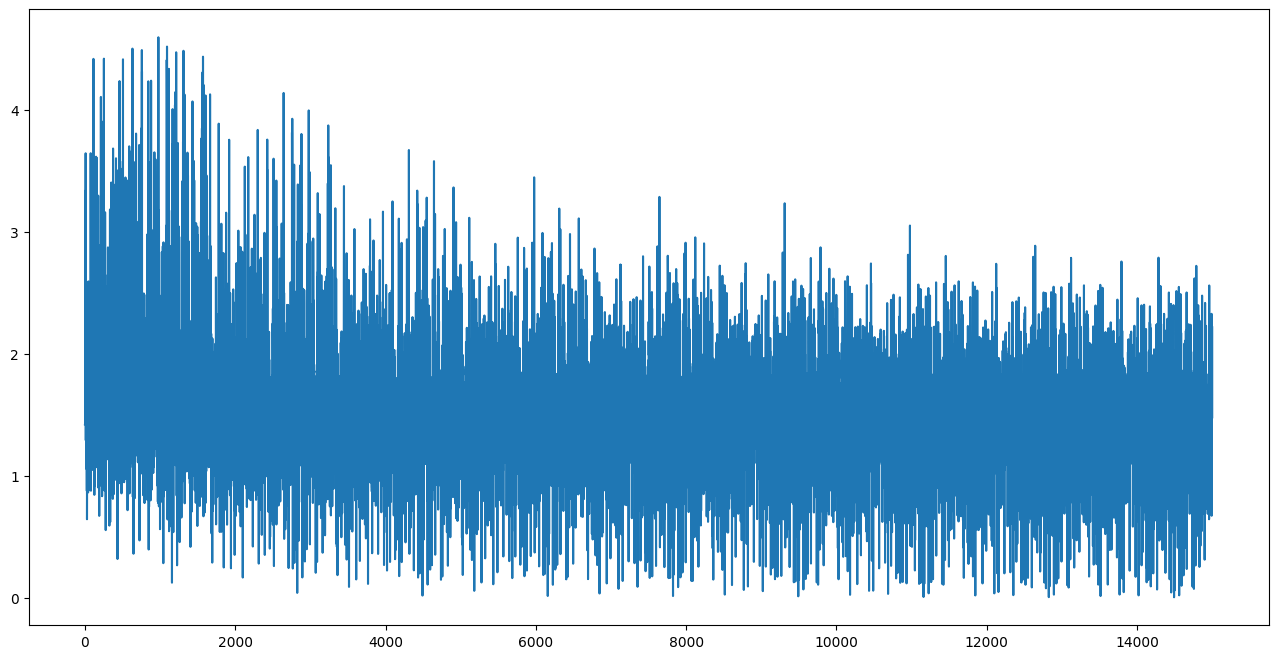

In [192]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
# plt.subplot(1,2,1)
plt.plot(range(15003), entropy_list)
plt.show()

In [193]:
mv_avg_entropy_list

[1.805620259940622,
 1.7525231679975997,
 1.5842459373995668,
 1.5357319232150923,
 1.4957192135117952,
 1.4989379533305756,
 1.491645820698701,
 1.4618719662111255,
 1.4782266650591038,
 1.453129681962542,
 1.4456423574723318,
 1.4368809186588047,
 1.414844062257092,
 1.4416285993214697,
 1.4113908650844829]

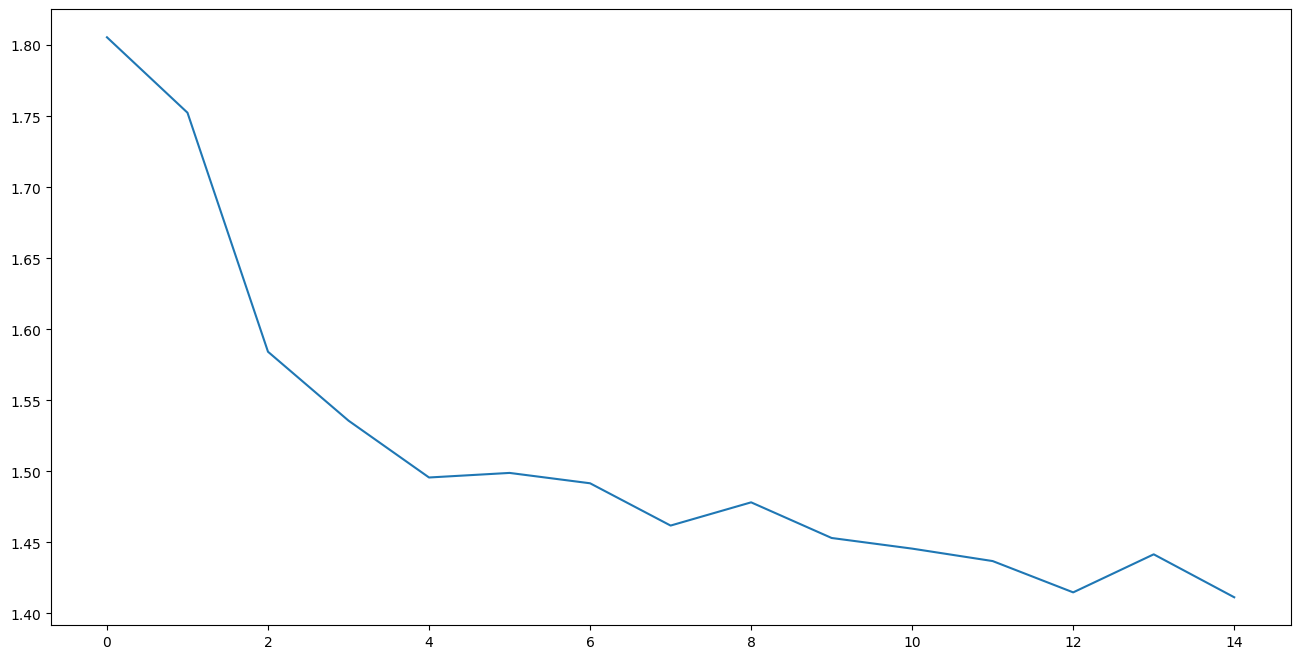

In [194]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
# plt.subplot(1,2,1)
plt.plot(mv_avg_entropy_list)
plt.show()

## baseline zero-shot

### exp1_visual_log_debug

In [13]:
json_path = "/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp1_visual_log_debug/i2t/20250615062/coeffi_list.json"
with open(json_path, "rt") as file:
    coeffi_list = json.load(file)
    coeffi_list = json.loads(coeffi_list)

print(coeffi_list[0].keys())

dict_keys(['recall_type', 'label', 'topk_sim', 'topk_idx', 'score', 'entropy_logits_softmax', 'entropy_sigmoid_sum', 'entropy_sigmoid_mean', 'entropy_softmax'])


In [14]:
neg_entropy_logits_softmax_list = []
r1_entropy_logits_softmax_list = []
r5_entropy_logits_softmax_list = []
r10_entropy_logits_softmax_list = []

neg_entropy_sigmoid_sum_list = []
r1_entropy_sigmoid_sum_list = []
r5_entropy_sigmoid_sum_list = []
r10_entropy_sigmoid_sum_list = []

neg_entropy_sigmoid_mean_list = []
r1_entropy_sigmoid_mean_list = []
r5_entropy_sigmoid_mean_list = []
r10_entropy_sigmoid_mean_list = []

neg_entropy_softmax_list = []
r1_entropy_softmax_list = []
r5_entropy_softmax_list = []
r10_entropy_softmax_list = []

for coeffi_dict in coeffi_list:
    if coeffi_dict['recall_type'] == "negative sample":
        neg_entropy_logits_softmax_list.append(coeffi_dict["entropy_logits_softmax"])
        neg_entropy_sigmoid_sum_list.append(coeffi_dict["entropy_sigmoid_sum"])
        neg_entropy_sigmoid_mean_list.append(coeffi_dict["entropy_sigmoid_mean"])
        neg_entropy_softmax_list.append(coeffi_dict["entropy_softmax"])
    elif coeffi_dict['recall_type'] == "recall@1":
        r1_entropy_logits_softmax_list.append(coeffi_dict["entropy_logits_softmax"])
        r1_entropy_sigmoid_sum_list.append(coeffi_dict["entropy_sigmoid_sum"])
        r1_entropy_sigmoid_mean_list.append(coeffi_dict["entropy_sigmoid_mean"])
        r1_entropy_softmax_list.append(coeffi_dict["entropy_softmax"])
    elif coeffi_dict['recall_type'] == "recall@5":
        r5_entropy_logits_softmax_list.append(coeffi_dict["entropy_logits_softmax"])
        r5_entropy_sigmoid_sum_list.append(coeffi_dict["entropy_sigmoid_sum"])
        r5_entropy_sigmoid_mean_list.append(coeffi_dict["entropy_sigmoid_mean"])
        r5_entropy_softmax_list.append(coeffi_dict["entropy_softmax"])
    elif coeffi_dict['recall_type'] == "recall@10":
        r10_entropy_logits_softmax_list.append(coeffi_dict["entropy_logits_softmax"])
        r10_entropy_sigmoid_sum_list.append(coeffi_dict["entropy_sigmoid_sum"])
        r10_entropy_sigmoid_mean_list.append(coeffi_dict["entropy_sigmoid_mean"])
        r10_entropy_softmax_list.append(coeffi_dict["entropy_softmax"])

print("length statistics: neg r1 r5 r10")
print(len(neg_entropy_logits_softmax_list), len(r1_entropy_logits_softmax_list), len(r5_entropy_logits_softmax_list), len(r10_entropy_logits_softmax_list))

print()
print("entropy_logits_softmax statistics: mean max min median")
print("neg: ", np.mean(neg_entropy_logits_softmax_list), np.max(neg_entropy_logits_softmax_list), np.min(neg_entropy_logits_softmax_list), np.median(neg_entropy_logits_softmax_list))
print("r1: ", np.mean(r1_entropy_logits_softmax_list), np.max(r1_entropy_logits_softmax_list), np.min(r1_entropy_logits_softmax_list), np.median(r1_entropy_logits_softmax_list))
print("r5: ", np.mean(r5_entropy_logits_softmax_list), np.max(r5_entropy_logits_softmax_list), np.min(r5_entropy_logits_softmax_list), np.median(r5_entropy_logits_softmax_list))
print("r10: ", np.mean(r10_entropy_logits_softmax_list), np.max(r10_entropy_logits_softmax_list), np.min(r10_entropy_logits_softmax_list), np.median(r10_entropy_logits_softmax_list))

print()
print("entropy_sigmoid_sum statistics: mean max min median")
print("neg: ", np.mean(neg_entropy_sigmoid_sum_list), np.max(neg_entropy_sigmoid_sum_list), np.min(neg_entropy_sigmoid_sum_list), np.median(neg_entropy_sigmoid_sum_list))
print("r1: ", np.mean(r1_entropy_sigmoid_sum_list), np.max(r1_entropy_sigmoid_sum_list), np.min(r1_entropy_sigmoid_sum_list), np.median(r1_entropy_sigmoid_sum_list))
print("r5: ", np.mean(r5_entropy_sigmoid_sum_list), np.max(r5_entropy_sigmoid_sum_list), np.min(r5_entropy_sigmoid_sum_list), np.median(r5_entropy_sigmoid_sum_list))
print("r10: ", np.mean(r10_entropy_sigmoid_sum_list), np.max(r10_entropy_sigmoid_sum_list), np.min(r10_entropy_sigmoid_sum_list), np.median(r10_entropy_sigmoid_sum_list))

print()
print("entropy_sigmoid_mean statistics: mean max min median")
print("neg: ", np.mean(neg_entropy_sigmoid_mean_list), np.max(neg_entropy_sigmoid_mean_list), np.min(neg_entropy_sigmoid_mean_list), np.median(neg_entropy_sigmoid_mean_list))
print("r1: ", np.mean(r1_entropy_sigmoid_mean_list), np.max(r1_entropy_sigmoid_mean_list), np.min(r1_entropy_sigmoid_mean_list), np.median(r1_entropy_sigmoid_mean_list))
print("r5: ", np.mean(r5_entropy_sigmoid_mean_list), np.max(r5_entropy_sigmoid_mean_list), np.min(r5_entropy_sigmoid_mean_list), np.median(r5_entropy_sigmoid_mean_list))
print("r10: ", np.mean(r10_entropy_sigmoid_mean_list), np.max(r10_entropy_sigmoid_mean_list), np.min(r10_entropy_sigmoid_mean_list), np.median(r10_entropy_sigmoid_mean_list))

print()
print("entropy_softmax statistics: mean max min median")
print("neg: ", np.mean(neg_entropy_softmax_list), np.max(neg_entropy_softmax_list), np.min(neg_entropy_softmax_list), np.median(neg_entropy_softmax_list))
print("r1: ", np.mean(r1_entropy_softmax_list), np.max(r1_entropy_softmax_list), np.min(r1_entropy_softmax_list), np.median(r1_entropy_softmax_list))
print("r5: ", np.mean(r5_entropy_softmax_list), np.max(r5_entropy_softmax_list), np.min(r5_entropy_softmax_list), np.median(r5_entropy_softmax_list))
print("r10: ", np.mean(r10_entropy_softmax_list), np.max(r10_entropy_softmax_list), np.min(r10_entropy_softmax_list), np.median(r10_entropy_softmax_list))


length statistics: neg r1 r5 r10
129 3718 993 160

entropy_logits_softmax statistics: mean max min median
neg:  0.5233863390000292 0.6614187955856323 0.1858476996421814 0.5671491622924805
r1:  0.19652268542011878 0.6587494015693665 0.021482639014720917 0.15978538990020752
r5:  0.3017209417187615 0.6587955951690674 0.04326862096786499 0.2828522324562073
r10:  0.4192287757992744 0.6598516702651978 0.08506316691637039 0.3957221508026123

entropy_sigmoid_sum statistics: mean max min median
neg:  42.35452916640644 46.06053161621094 21.82415008544922 44.215362548828125
r1:  26.730166004574894 45.769744873046875 8.571356773376465 25.70218276977539
r5:  33.21098616332086 45.73759460449219 12.00213623046875 33.971580505371094
r10:  38.79140100479126 45.80486297607422 15.650642395019531 39.878265380859375

entropy_sigmoid_mean statistics: mean max min median
neg:  0.3308947591125503 0.35984790325164795 0.17050117254257202 0.3454325199127197
r1:  0.20882942191074136 0.3575761318206787 0.066963724

### exp7

In [ ]:
json_path = "/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp7/i2t/20250616193/epoch-1_logging_list.json"
with open(json_path, "rt") as file:
    coeffi_list = json.load(file)
    coeffi_list = json.loads(coeffi_list)

print(coeffi_list[0].keys())

dict_keys(['recall_type', 'label', 'topk_sim', 'topk_idx', 'score', 'entropy_logits_softmax', 'entropy_sigmoid_sum', 'entropy_sigmoid_mean', 'entropy_softmax'])


In [16]:
neg_entropy_logits_softmax_list = []
r1_entropy_logits_softmax_list = []
r5_entropy_logits_softmax_list = []
r10_entropy_logits_softmax_list = []

neg_entropy_sigmoid_sum_list = []
r1_entropy_sigmoid_sum_list = []
r5_entropy_sigmoid_sum_list = []
r10_entropy_sigmoid_sum_list = []

neg_entropy_sigmoid_mean_list = []
r1_entropy_sigmoid_mean_list = []
r5_entropy_sigmoid_mean_list = []
r10_entropy_sigmoid_mean_list = []

neg_entropy_softmax_list = []
r1_entropy_softmax_list = []
r5_entropy_softmax_list = []
r10_entropy_softmax_list = []

for coeffi_dict in coeffi_list:
    if coeffi_dict['recall_type'] == "negative sample":
        neg_entropy_logits_softmax_list.append(coeffi_dict["entropy_logits_softmax"])
        neg_entropy_sigmoid_sum_list.append(coeffi_dict["entropy_sigmoid_sum"])
        neg_entropy_sigmoid_mean_list.append(coeffi_dict["entropy_sigmoid_mean"])
        neg_entropy_softmax_list.append(coeffi_dict["entropy_softmax"])
    elif coeffi_dict['recall_type'] == "recall@1":
        r1_entropy_logits_softmax_list.append(coeffi_dict["entropy_logits_softmax"])
        r1_entropy_sigmoid_sum_list.append(coeffi_dict["entropy_sigmoid_sum"])
        r1_entropy_sigmoid_mean_list.append(coeffi_dict["entropy_sigmoid_mean"])
        r1_entropy_softmax_list.append(coeffi_dict["entropy_softmax"])
    elif coeffi_dict['recall_type'] == "recall@5":
        r5_entropy_logits_softmax_list.append(coeffi_dict["entropy_logits_softmax"])
        r5_entropy_sigmoid_sum_list.append(coeffi_dict["entropy_sigmoid_sum"])
        r5_entropy_sigmoid_mean_list.append(coeffi_dict["entropy_sigmoid_mean"])
        r5_entropy_softmax_list.append(coeffi_dict["entropy_softmax"])
    elif coeffi_dict['recall_type'] == "recall@10":
        r10_entropy_logits_softmax_list.append(coeffi_dict["entropy_logits_softmax"])
        r10_entropy_sigmoid_sum_list.append(coeffi_dict["entropy_sigmoid_sum"])
        r10_entropy_sigmoid_mean_list.append(coeffi_dict["entropy_sigmoid_mean"])
        r10_entropy_softmax_list.append(coeffi_dict["entropy_softmax"])

print("length statistics: neg r1 r5 r10")
print(len(neg_entropy_logits_softmax_list), len(r1_entropy_logits_softmax_list), len(r5_entropy_logits_softmax_list), len(r10_entropy_logits_softmax_list))

print()
print("entropy_logits_softmax statistics: mean max min median")
print("neg: ", np.mean(neg_entropy_logits_softmax_list), np.max(neg_entropy_logits_softmax_list), np.min(neg_entropy_logits_softmax_list), np.median(neg_entropy_logits_softmax_list))
print("r1: ", np.mean(r1_entropy_logits_softmax_list), np.max(r1_entropy_logits_softmax_list), np.min(r1_entropy_logits_softmax_list), np.median(r1_entropy_logits_softmax_list))
print("r5: ", np.mean(r5_entropy_logits_softmax_list), np.max(r5_entropy_logits_softmax_list), np.min(r5_entropy_logits_softmax_list), np.median(r5_entropy_logits_softmax_list))
print("r10: ", np.mean(r10_entropy_logits_softmax_list), np.max(r10_entropy_logits_softmax_list), np.min(r10_entropy_logits_softmax_list), np.median(r10_entropy_logits_softmax_list))

print()
print("entropy_sigmoid_sum statistics: mean max min median")
print("neg: ", np.mean(neg_entropy_sigmoid_sum_list), np.max(neg_entropy_sigmoid_sum_list), np.min(neg_entropy_sigmoid_sum_list), np.median(neg_entropy_sigmoid_sum_list))
print("r1: ", np.mean(r1_entropy_sigmoid_sum_list), np.max(r1_entropy_sigmoid_sum_list), np.min(r1_entropy_sigmoid_sum_list), np.median(r1_entropy_sigmoid_sum_list))
print("r5: ", np.mean(r5_entropy_sigmoid_sum_list), np.max(r5_entropy_sigmoid_sum_list), np.min(r5_entropy_sigmoid_sum_list), np.median(r5_entropy_sigmoid_sum_list))
print("r10: ", np.mean(r10_entropy_sigmoid_sum_list), np.max(r10_entropy_sigmoid_sum_list), np.min(r10_entropy_sigmoid_sum_list), np.median(r10_entropy_sigmoid_sum_list))

print()
print("entropy_sigmoid_mean statistics: mean max min median")
print("neg: ", np.mean(neg_entropy_sigmoid_mean_list), np.max(neg_entropy_sigmoid_mean_list), np.min(neg_entropy_sigmoid_mean_list), np.median(neg_entropy_sigmoid_mean_list))
print("r1: ", np.mean(r1_entropy_sigmoid_mean_list), np.max(r1_entropy_sigmoid_mean_list), np.min(r1_entropy_sigmoid_mean_list), np.median(r1_entropy_sigmoid_mean_list))
print("r5: ", np.mean(r5_entropy_sigmoid_mean_list), np.max(r5_entropy_sigmoid_mean_list), np.min(r5_entropy_sigmoid_mean_list), np.median(r5_entropy_sigmoid_mean_list))
print("r10: ", np.mean(r10_entropy_sigmoid_mean_list), np.max(r10_entropy_sigmoid_mean_list), np.min(r10_entropy_sigmoid_mean_list), np.median(r10_entropy_sigmoid_mean_list))

print()
print("entropy_softmax statistics: mean max min median")
print("neg: ", np.mean(neg_entropy_softmax_list), np.max(neg_entropy_softmax_list), np.min(neg_entropy_softmax_list), np.median(neg_entropy_softmax_list))
print("r1: ", np.mean(r1_entropy_softmax_list), np.max(r1_entropy_softmax_list), np.min(r1_entropy_softmax_list), np.median(r1_entropy_softmax_list))
print("r5: ", np.mean(r5_entropy_softmax_list), np.max(r5_entropy_softmax_list), np.min(r5_entropy_softmax_list), np.median(r5_entropy_softmax_list))
print("r10: ", np.mean(r10_entropy_softmax_list), np.max(r10_entropy_softmax_list), np.min(r10_entropy_softmax_list), np.median(r10_entropy_softmax_list))


length statistics: neg r1 r5 r10
129 3719 992 160

entropy_logits_softmax statistics: mean max min median
neg:  0.5233863390000292 0.6614187955856323 0.1858476996421814 0.5671491622924805
r1:  0.19648579175704972 0.6587494015693665 0.021482639014720917 0.15976855158805847
r5:  0.3019653023934112 0.6587955951690674 0.04326862096786499 0.2829769402742386
r10:  0.4192287757992744 0.6598516702651978 0.08506316691637039 0.3957221508026123

entropy_sigmoid_sum statistics: mean max min median
neg:  42.35452916640644 46.06053161621094 21.82415008544922 44.215362548828125
r1:  26.72620579221294 45.769744873046875 8.571356773376465 25.698230743408203
r5:  33.232366052366075 45.73759460449219 12.051183700561523 34.01615333557129
r10:  38.79140100479126 45.80486297607422 15.650642395019531 39.878265380859375

entropy_sigmoid_mean statistics: mean max min median
neg:  0.3308947591125503 0.35984790325164795 0.17050117254257202 0.3454325199127197
r1:  0.2087984827516636 0.3575761318206787 0.066963724

# 负样本采样后 score.show()

## top1和其余15个负样本的差异
- batch = pos(top1) + neg(15 * sampling from top32~128)

### top(32,128)

In [29]:
import torch
import torch.nn.functional as F

score_32_128 = torch.Tensor([[ 3.5667, -2.8287, -6.3197, -4.7724, -2.6105, -3.2053, -4.2531, -4.4329,
         -3.9197, -3.1590, -5.6936, -3.6822, -1.2667, -2.8792, -2.8216, -1.0740],
        [ 2.5099, -4.1357, -5.4952, -3.1999, -6.0585, -1.2038, -3.8756, -2.7068,
         -2.1692, -2.5481, -4.3602, -0.8354, -3.6226, -4.9880, -5.4860, -0.8545],
        [ 2.1975, -1.4912, -1.6474, -2.5968, -3.1348, -1.1771, -1.7994, -5.1716,
         -1.4218, -2.7125, -0.1381, -0.4673, -0.2047, -1.2380, -0.2625, -4.2207],
        [ 3.0514, -2.6248, -0.5111, -1.3498, -1.2535, -2.4860, -1.3664, -1.5828,
         -1.4646, -2.5590, -2.7638, -3.0482, -3.8081, -4.1487, -1.8235, -1.8222],
        [ 3.0197, -3.4594, -4.7157, -5.9915, -4.4762, -5.4324, -5.1149, -3.4077,
         -5.2341, -3.6322, -4.8053, -6.3458, -3.0771, -1.0846, -6.7638, -4.2946],
        [ 2.2184, -5.9113, -1.1773, -0.6776, -5.6835, -2.0352, -1.2113, -5.8816,
         -1.2113, -5.9439, -5.5331, -3.7744, -5.2804, -6.1658, -3.0847, -6.8215],
        [ 1.8080, -0.4717, -0.9795, -0.6314, -0.4442,  0.0852, -0.5305, -1.2425,
         -0.1826, -3.1122, -0.5502, -0.1762, -0.2559, -0.1787, -0.5581, -0.5875],
        [ 0.8276, -0.8725, -0.3617, -0.4739, -0.4370, -3.5637, -1.7056, -0.2597,
         -1.0400, -1.2157, -0.5729, -0.6318, -3.0906, -1.2979, -0.9477, -0.3276]],)

proba = F.softmax(score_32_128 , dim=-1)
entropy = -(F.softmax(score_32_128 , dim=-1) * F.log_softmax(score_32_128 , dim=-1)).sum(-1)

# entropy =tensor([0.1864, 0.5617, 1.4233, 0.5962, 0.1572, 0.6887, 2.2401, 2.4491],)

In [30]:
entropy.mean()

tensor(1.0378)

In [31]:
# proba = tensor([[9.7147e-01, 1.6216e-03, 4.9411e-05, 2.3217e-04, 2.0170e-03, 1.1127e-03,
                #  3.9024e-04, 3.2602e-04, 5.4466e-04, 1.1655e-03, 9.2413e-05, 6.9068e-04,
                #  7.7324e-03, 1.5417e-03, 1.6332e-03, 9.3756e-03],
                # [8.8793e-01, 1.1541e-03, 2.9635e-04, 2.9420e-03, 1.6872e-04, 2.1654e-02,
                #  1.4969e-03, 4.8172e-03, 8.2465e-03, 5.6457e-03, 9.2200e-04, 3.1299e-02,
                #  1.9278e-03, 4.9213e-04, 2.9909e-04, 3.0707e-02],
                # [6.5657e-01, 1.6417e-02, 1.4043e-02, 5.4343e-03, 3.1732e-03, 2.2476e-02,
                #  1.2063e-02, 4.1392e-04, 1.7597e-02, 4.8405e-03, 6.3525e-02, 4.5706e-02,
                #  5.9432e-02, 2.1148e-02, 5.6094e-02, 1.0713e-03],
                # [8.9272e-01, 3.0590e-03, 2.5325e-02, 1.0947e-02, 1.2054e-02, 3.5144e-03,
                #  1.0767e-02, 8.6718e-03, 9.7599e-03, 3.2670e-03, 2.6620e-03, 2.0031e-03,
                #  9.3686e-04, 6.6643e-04, 6.8167e-03, 6.8256e-03],
                # [9.7439e-01, 1.4959e-03, 4.2588e-04, 1.1891e-04, 5.4113e-04, 2.0798e-04,
                #  2.8571e-04, 1.5752e-03, 2.5360e-04, 1.2585e-03, 3.8938e-04, 8.3435e-05,
                #  2.1924e-03, 1.6079e-02, 5.4930e-05, 6.4889e-04],
                # [8.4902e-01, 2.5017e-04, 2.8457e-02, 4.6903e-02, 3.1417e-04, 1.2067e-02,
                #  2.7506e-02, 2.5771e-04, 2.7506e-02, 2.4215e-04, 3.6516e-04, 2.1197e-03,
                #  4.7015e-04, 1.9396e-04, 4.2249e-03, 1.0068e-04],
                # [3.9941e-01, 4.0865e-02, 2.4593e-02, 3.4834e-02, 4.2005e-02, 7.1320e-02,
                #  3.8532e-02, 1.8906e-02, 5.4564e-02, 2.9147e-03, 3.7780e-02, 5.4915e-02,
                #  5.0708e-02, 5.4778e-02, 3.7483e-02, 3.6397e-02],
                # [2.5926e-01, 4.7358e-02, 7.8928e-02, 7.0551e-02, 7.3203e-02, 3.2109e-03,
                #  2.0587e-02, 8.7404e-02, 4.0054e-02, 3.3600e-02, 6.3901e-02, 6.0246e-02,
                #  5.1533e-03, 3.0949e-02, 4.3927e-02, 8.1666e-02]])

In [32]:
print("max min mean median std ")
print(proba.max(), proba.min(), proba.mean(), proba.median(), proba.std())
print("neg.max neg.min neg.mean neg.median neg.std")
print(proba[:, 1:].max(), proba[:, 1:].min(), proba[:, 1:].mean(), proba[:, 1:].median(), proba[:, 1:].std())

max min mean median std 
tensor(0.9744) tensor(4.9411e-05) tensor(0.0625) tensor(0.0068) tensor(0.1873)
neg.max neg.min neg.mean neg.median neg.std
tensor(0.0874) tensor(4.9411e-05) tensor(0.0176) tensor(0.0048) tensor(0.0227)


### top(10,32)

In [22]:
score = torch.Tensor([[ 3.5667e+00, -6.9058e-01, -4.1775e-01, -1.6234e+00,  1.1297e-01,
         -6.5784e-02, -2.5333e+00, -5.4269e-01, -1.2514e+00, -2.1594e+00,
          3.6940e-02, -6.5690e-01, -4.7195e+00, -2.1366e+00, -3.3198e+00,
          1.6008e-02],
        [ 2.5099e+00, -2.3676e+00, -1.1363e+00, -1.4455e+00, -4.4448e+00,
         -3.5131e+00, -2.9808e+00, -5.7891e-01, -1.9893e+00, -1.8585e+00,
         -5.8675e-01, -1.6773e+00, -3.0267e+00, -4.9869e+00, -3.0792e+00,
         -7.8207e-01],
        [ 2.1975e+00, -4.9136e-01, -6.2768e-01, -1.5989e+00, -1.5761e+00,
         -2.6872e+00, -1.3661e+00, -3.8252e+00, -2.2036e+00, -2.1952e+00,
         -8.2297e-01, -8.6833e-01, -9.7158e-01, -1.5473e+00, -3.3040e-01,
         -1.3729e+00],
        [ 3.0514e+00, -1.1324e+00, -1.5955e-01, -9.5334e-01,  2.4388e-03,
          2.9186e-02,  1.2899e-02,  4.5299e-01, -9.2271e-01, -1.3789e-01,
         -1.5055e-01, -1.7621e+00, -1.2162e+00, -3.0868e+00,  1.4442e-01,
          1.0188e-01],
        [ 3.0197e+00, -1.3416e+00, -1.3108e+00, -3.8227e+00, -2.2672e+00,
         -1.0626e+00, -1.3416e+00, -1.1635e+00, -1.4005e+00, -5.7134e+00,
         -1.3108e+00, -3.8252e+00, -4.7621e+00, -5.6966e+00, -1.3416e+00,
         -2.0278e+00],
        [ 2.2184e+00, -1.1491e+00, -4.1854e+00, -5.1513e+00, -5.6259e+00,
         -1.0168e+00, -2.5251e+00, -4.9787e+00, -3.1128e+00, -6.1040e+00,
         -2.9205e+00, -6.0969e+00, -5.9738e+00, -3.5540e+00, -5.5696e-01,
         -2.6209e+00],
        [ 1.8080e+00,  2.5629e-01,  1.5640e-01,  3.1635e-01,  1.1531e-01,
          5.7262e-01,  3.2249e-01,  1.5664e-01,  1.8648e-02,  6.6248e-02,
          1.8443e-01,  1.2287e+00, -1.1920e-01, -6.9018e-03, -7.3227e-01,
          8.5291e-02],
        [ 8.2762e-01, -3.6459e-01,  7.3355e-01, -1.3814e+00, -5.0589e-01,
         -6.3823e-01, -1.2063e+00, -1.8245e-01, -1.2114e-01, -1.1181e-01,
         -4.5947e-01,  5.4648e-02, -1.3585e+00, -6.6610e-02,  5.1530e-02,
         -3.1865e-01]],)

proba = F.softmax(score , dim=-1)
entropy = -(F.softmax(score , dim=-1) * F.log_softmax(score , dim=-1)).sum(-1)
# tensor([0.8523, 0.9163, 1.4701, 1.5096, 0.6028, 0.6701, 2.5396, 2.5951],

In [23]:
entropy.mean()

tensor(1.3945)

In [24]:
proba

tensor([[8.3078e-01, 1.1765e-02, 1.5455e-02, 4.6287e-03, 2.6275e-02, 2.1974e-02,
         1.8633e-03, 1.3640e-02, 6.7145e-03, 2.7082e-03, 2.4352e-02, 1.2167e-02,
         2.0933e-04, 2.7706e-03, 8.4863e-04, 2.3847e-02],
        [8.0938e-01, 6.1643e-03, 2.1117e-02, 1.5501e-02, 7.7227e-04, 1.9606e-03,
         3.3387e-03, 3.6872e-02, 8.9986e-03, 1.0256e-02, 3.6584e-02, 1.2294e-02,
         3.1889e-03, 4.4909e-04, 3.0258e-03, 3.0093e-02],
        [6.6459e-01, 4.5165e-02, 3.9409e-02, 1.4921e-02, 1.5265e-02, 5.0253e-03,
         1.8832e-02, 1.6104e-03, 8.1505e-03, 8.2192e-03, 3.2418e-02, 3.0980e-02,
         2.7941e-02, 1.5711e-02, 5.3052e-02, 1.8705e-02],
        [6.5610e-01, 9.9992e-03, 2.6453e-02, 1.1960e-02, 3.1104e-02, 3.1947e-02,
         3.1431e-02, 4.8808e-02, 1.2332e-02, 2.7032e-02, 2.6692e-02, 5.3271e-03,
         9.1954e-03, 1.4164e-03, 3.5849e-02, 3.4356e-02],
        [8.9038e-01, 1.1363e-02, 1.1718e-02, 9.5052e-04, 4.5030e-03, 1.5019e-02,
         1.1363e-02, 1.3578e-02, 1.0713

In [28]:
print("max min mean median std ")
print(proba.max(), proba.min(), proba.mean(), proba.median(), proba.std())
print("neg.max neg.min neg.mean neg.median neg.std")
print(proba[:, 1:].max(), proba[:, 1:].min(), proba[:, 1:].mean(), proba[:, 1:].median(), proba[:, 1:].std())

max min mean median std 
tensor(0.8904) tensor(0.0001) tensor(0.0625) tensor(0.0183) tensor(0.1652)
neg.max neg.min neg.mean neg.median neg.std
tensor(0.1485) tensor(0.0001) tensor(0.0241) tensor(0.0155) tensor(0.0250)


top32~128 proba:  
max min mean median std   
tensor(0.9744) tensor(4.9411e-05) tensor(0.0625) tensor(0.0068) tensor(0.1873)  
neg.max neg.min neg.mean neg.median neg.std  
tensor(0.0874) tensor(4.9411e-05) tensor(0.0176) tensor(0.0048) tensor(0.0227)  

top10~32 proba:  
max min mean median std   
tensor(0.8904) tensor(0.0001) tensor(0.0625) tensor(0.0183) tensor(0.1652)  
neg.max neg.min neg.mean neg.median neg.std  
tensor(0.1485) tensor(0.0001) tensor(0.0241) tensor(0.0155) tensor(0.0250)  

## i2t/t2i all score analysis

In [46]:
import json
import numpy as np
import torch
import torch.nn.functional as F

In [47]:
## zero-shot top128 score

with open("/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp9.1/i2t/20250624151/result/rank0_eval_epoch-1_logging_list.json", "rt") as file:
    print(type(file))
    score_i2t_str = json.load(file)
    score_i2t = json.loads(score_i2t_str)

# score_t2i = with open("/home/jiahao/task/LAVIS/lavis/output/BLIP2/Retrieval_COCO_itm_adapt_exp9.1/t2i/*********/result/rank0_eval_epoch-1_logging_list.json", "rt") as file:
#     print(type(file))
#     score_t2i_str = json.load(file)
#     score_t2i = json.loads(score_t2i_str)

<class '_io.TextIOWrapper'>


In [48]:
print(f"number of i2t samples : {len(score_i2t)}")

number of i2t samples : 5000


In [49]:
print(f"score_i2t[0].keys() : {score_i2t[0].keys()}")
print(f"score_i2t[0]['recall_type'] : {score_i2t[0]['recall_type'] }")
print(f"score_i2t[0]['topk_sim'] : {len(score_i2t[0]['topk_sim']) }")
print(f"score_i2t[0]['score'] : {len(score_i2t[0]['score'])  }")
print(f"score_i2t[0]['top128_entropy'] : {score_i2t[0]['entropy'] }")
# print(f"score_i2t[0]['recall_type'] : {score_i2t[0]['recall_type'] }")

score_i2t[0].keys() : dict_keys(['recall_type', 'label', 'topk_sim', 'topk_idx', 'score', 'entropy'])
score_i2t[0]['recall_type'] : recall@1
score_i2t[0]['topk_sim'] : 128
score_i2t[0]['score'] : 128
score_i2t[0]['top128_entropy'] : 2.258613348007202


### zero-shot visual

In [73]:
def show_score_stats(score_i2t):
    neg_topk_sim_list = []
    r1_topk_sim_list = []
    r5_topk_sim_list = []
    r10_topk_sim_list = []

    neg_score_list = []
    r1_score_list = []
    r5_score_list = []
    r10_score_list = []

    neg_entropy_list = []
    r1_entropy_list = []
    r5_entropy_list = []
    r10_entropy_list = []

    for score_dict in score_i2t:
        if score_dict['recall_type'] == "negative sample":
            neg_topk_sim_list.append(score_dict["topk_sim"])
            neg_score_list.append(score_dict["score"])
            neg_entropy_list.append(score_dict["entropy"])
        elif score_dict['recall_type'] == "recall@1":
            r1_topk_sim_list.append(score_dict["topk_sim"])
            r1_score_list.append(score_dict["score"])
            r1_entropy_list.append(score_dict["entropy"])
        elif score_dict['recall_type'] == "recall@5":
            r5_topk_sim_list.append(score_dict["topk_sim"])
            r5_score_list.append(score_dict["score"])
            r5_entropy_list.append(score_dict["entropy"])
        elif score_dict['recall_type'] == "recall@10":
            r10_topk_sim_list.append(score_dict["topk_sim"])
            r10_score_list.append(score_dict["score"])
            r10_entropy_list.append(score_dict["entropy"])

    print("length statistics: neg r1 r5 r10")
    print(len(neg_entropy_list), len(r1_entropy_list), len(r5_entropy_list), len(r10_entropy_list))

    print()
    print("topk_sim statistics: mean max min median")
    print("neg: ", np.mean(neg_topk_sim_list), np.max(neg_topk_sim_list), np.min(neg_topk_sim_list), np.median(neg_topk_sim_list))
    print("r1: ", np.mean(r1_topk_sim_list), np.max(r1_topk_sim_list), np.min(r1_topk_sim_list), np.median(r1_topk_sim_list))
    print("r5: ", np.mean(r5_topk_sim_list), np.max(r5_topk_sim_list), np.min(r5_topk_sim_list), np.median(r5_topk_sim_list))
    print("r10: ", np.mean(r10_topk_sim_list), np.max(r10_topk_sim_list), np.min(r10_topk_sim_list), np.median(r10_topk_sim_list))

    print()
    print("score statistics: mean max min median")
    print("neg: ", np.mean(neg_score_list), np.max(neg_score_list), np.min(neg_score_list), np.median(neg_score_list))
    print("r1: ",np.mean(r1_score_list), np.max(r1_score_list), np.min(r1_score_list), np.median(r1_score_list))
    print("r5: ", np.mean(r5_score_list), np.max(r5_score_list), np.min(r5_score_list), np.median(r5_score_list))
    print("r10: ", np.mean(r10_score_list), np.max(r10_score_list), np.min(r10_score_list), np.median(r10_score_list))

    print()
    print("entropy statistics: mean max min median")
    print("neg: ", np.mean(neg_entropy_list), np.max(neg_entropy_list), np.min(neg_entropy_list), np.median(neg_entropy_list))
    print("r1: ",np.mean(r1_entropy_list), np.max(r1_entropy_list), np.min(r1_entropy_list), np.median(r1_entropy_list))
    print("r5: ", np.mean(r5_entropy_list), np.max(r5_entropy_list), np.min(r5_entropy_list), np.median(r5_entropy_list))
    print("r10: ", np.mean(r10_entropy_list), np.max(r10_entropy_list), np.min(r10_entropy_list), np.median(r10_entropy_list))


In [74]:
show_score_stats(score_i2t)

length statistics: neg r1 r5 r10
129 3719 992 160

topk_sim statistics: mean max min median
neg:  0.45498764363131955 0.5569778084754944 0.3479570746421814 0.45595912635326385
r1:  0.40107592666330344 0.6125096678733826 0.29702228307724 0.39300617575645447
r5:  0.4239975187581055 0.5953502058982849 0.3045620620250702 0.42081499099731445
r10:  0.44136907769425304 0.5820091366767883 0.32159551978111267 0.44188548624515533

score statistics: mean max min median
neg:  -0.5634530126257895 3.062492847442627 -6.772589206695557 -0.27657903730869293
r1:  -2.2508195916908176 5.611236572265625 -7.543262481689453 -2.1215819120407104
r5:  -1.5417760368244828 4.86556339263916 -7.369493007659912 -1.1519781351089478
r10:  -0.9630478420171016 4.1121392250061035 -7.233804702758789 -0.5411417782306671

entropy statistics: mean max min median
neg:  4.635891942090766 4.8412394523620605 3.362489700317383 4.731634140014648
r1:  3.0667954509570476 4.836906909942627 1.1115614175796509 3.0329437255859375
r5:  3

### top32-128

In [101]:
## 负样本采样方法
def sample_neg_idxs(sims_matrix_i2t, k_tta, k_test, neg_sample_range=[32, 128]):
    num_images, num_texts = sims_matrix_i2t.shape
    neg_idxs = []
    neg_sims = []
    for i in range(num_images):
        topk_sim_i2t, topk_idx_i2t = sims_matrix_i2t[i].topk(k=k_test, dim=0)
        # random_idx = torch.randperm(k_test-2*k_tta)[:k_tta-1] + 2*k_tta # 随机采样k_tta-1个负样本索引
        random_idx = torch.randperm(neg_sample_range[1] - neg_sample_range[0])[:k_tta-1] + neg_sample_range[0]
        # print(random_idx)
        neg_sims.append(topk_sim_i2t[random_idx])
        neg_idxs.append(topk_idx_i2t[random_idx])
    return torch.stack(neg_sims, dim=0), torch.stack(neg_idxs, dim=0)



In [102]:
sims_matrix_i2t = torch.from_numpy(np.load("debug_sim_matrix_i2t.npy"))

In [103]:
## 正样本取top1
top1_sims, top1_idxs = sims_matrix_i2t.topk(k=1, dim=1) #正样本直接使用top1 TODO 使用top5采样一个正样本？
top1_sims, top1_idxs =top1_sims[:,0], top1_idxs[:,0]
print(top1_idxs.shape)
print(top1_idxs[0])

## 负样本取top32-128采样15个
neg_sims, neg_idxs = sample_neg_idxs(sims_matrix_i2t, 16, 128, neg_sample_range=[32, 128])
print(neg_idxs.shape)
print(neg_idxs[0])

torch.Size([5000])
tensor(4)
torch.Size([5000, 15])
tensor([13787, 18760, 17826,  2836,  3948, 11242,   729,  5697,  3544,  5698,
         3784,  3664, 11870, 16816, 10023])


In [104]:
## 拼接正负样本至同一个sample
sampled_sims_matrix_i2t = []
sampled_sims_idx_i2t = []
for i in range(sims_matrix_i2t.size(0)):
    sampled_sim = torch.concatenate((sims_matrix_i2t[i,top1_idxs[i]].reshape(-1), sims_matrix_i2t[i,neg_idxs[i]]))
    sampled_idx = torch.concatenate((top1_idxs[i].reshape(-1), neg_idxs[i]))
    sampled_sims_matrix_i2t.append(sampled_sim)
    sampled_sims_idx_i2t.append(sampled_idx)
sampled_sims_matrix_i2t = torch.stack(sampled_sims_matrix_i2t) # shape=(5000, k_tta)
sampled_sims_idx_i2t = torch.stack(sampled_sims_idx_i2t) # shape=(5000, k_tta)

In [105]:
## 采样后show sample
print(sampled_sims_matrix_i2t.shape)
print(sampled_sims_matrix_i2t[0])
print()
print(sampled_sims_idx_i2t.shape)
print(sampled_sims_idx_i2t[0])

torch.Size([5000, 16])
tensor([0.5555, 0.4005, 0.3707, 0.3893, 0.3694, 0.3743, 0.3802, 0.3990, 0.3836,
        0.3912, 0.4081, 0.4050, 0.3696, 0.3802, 0.3647, 0.3661])

torch.Size([5000, 16])
tensor([    4, 13787, 18760, 17826,  2836,  3948, 11242,   729,  5697,  3544,
         5698,  3784,  3664, 11870, 16816, 10023])


In [106]:
## 使用上述采样后的index，在score_dict中找到对应的score
sampled_score_i2t = []
for score_dict, sampled_sims_idx in zip(score_i2t, sampled_sims_idx_i2t):
    # score_i2t[0].keys() : dict_keys(['recall_type', 'label', 'topk_sim', 'topk_idx', 'score', 'entropy'])
    sampled_idx = []
    sampled_sim = []
    sampled_score = []
    # print(sampled_sims_idx)
    for idx, sim, score in zip(score_dict["topk_idx"], score_dict["topk_sim"], score_dict["score"]):
        if idx in sampled_sims_idx:
            # print(idx)
            # print(sim)
            # print(score)
            sampled_idx.append(idx)
            sampled_sim.append(sim)
            sampled_score.append(score)
    score_dict_sampled = {
        'recall_type': score_dict["recall_type"], 
        'label': score_dict["label"], 
        'topk_sim': sampled_sim, 
        'topk_idx': sampled_idx, 
        'score': sampled_score, 
    }
    sampled_score_i2t.append(score_dict_sampled)

    # break

In [ ]:
print(f"len(sampled_score_i2t) : {len(sampled_score_i2t)}")
print(f"sampled_score_i2t[0].keys() : {sampled_score_i2t[0].keys()}")
print(f"sampled_score_i2t[0]['recall_type'] : {sampled_score_i2t[0]['recall_type']}")
print(f"sampled_score_i2t[0]['topk_sim'] : {sampled_score_i2t[0]['topk_sim']}")
print(f"sampled_score_i2t[0]['topk_idx'] : {sampled_score_i2t[0]['topk_idx']}")
print(f"sampled_score_i2t[0]['score'] : {sampled_score_i2t[0]['score']}")

len(sampled_score_i2t) : 5000
sampled_score_i2t[0].keys() : dict_keys(['recall_type', 'label', 'topk_sim', 'topk_idx', 'score'])
sampled_score_i2t[0]['recall_type'] : recall@1
sampled_score_i2t[0]['topk_sim'] : [0.5554964542388916, 0.4080696702003479, 0.4049654006958008, 0.4004947543144226, 0.3990207612514496, 0.39123180508613586, 0.38930898904800415, 0.3835560381412506, 0.3801591992378235, 0.38015469908714294, 0.3743467628955841, 0.3707039952278137, 0.36955007910728455, 0.3694497346878052, 0.36605170369148254, 0.3646582365036011]
sampled_score_i2t[0]['topk_idx'] : [4, 5698, 3784, 13787, 729, 3544, 17826, 5697, 11870, 11242, 3948, 18760, 3664, 2836, 10023, 16816]
sampled_score_i2t[0]['score'] : [3.5666849613189697, -3.96278715133667, -0.8795530796051025, -2.7258245944976807, -2.9429948329925537, -3.638624906539917, -2.672314167022705, -3.9798903465270996, -4.0500617027282715, -1.3125765323638916, -3.2058568000793457, -3.682236909866333, -4.231313228607178, -4.870689392089844, -3.560166

### top10-32

In [108]:
neg_sample_range = [10, 32]

In [109]:
## 正样本取top1
top1_sims, top1_idxs = sims_matrix_i2t.topk(k=1, dim=1) #正样本直接使用top1 TODO 使用top5采样一个正样本？
top1_sims, top1_idxs =top1_sims[:,0], top1_idxs[:,0]
print(top1_idxs.shape)
print(top1_idxs[0])

## 负样本取top32-128采样15个
neg_sims, neg_idxs = sample_neg_idxs(sims_matrix_i2t, 16, 128, neg_sample_range=neg_sample_range)
print(neg_idxs.shape)
print(neg_idxs[0])

## 拼接正负样本至同一个sample
sampled_sims_matrix_i2t = []
sampled_sims_idx_i2t = []
for i in range(sims_matrix_i2t.size(0)):
    sampled_sim = torch.concatenate((sims_matrix_i2t[i,top1_idxs[i]].reshape(-1), sims_matrix_i2t[i,neg_idxs[i]]))
    sampled_idx = torch.concatenate((top1_idxs[i].reshape(-1), neg_idxs[i]))
    sampled_sims_matrix_i2t.append(sampled_sim)
    sampled_sims_idx_i2t.append(sampled_idx)
sampled_sims_matrix_i2t = torch.stack(sampled_sims_matrix_i2t) # shape=(5000, k_tta)
sampled_sims_idx_i2t = torch.stack(sampled_sims_idx_i2t) # shape=(5000, k_tta)

## 采样后show sample
print(sampled_sims_matrix_i2t.shape)
print(sampled_sims_matrix_i2t[0])
print()
print(sampled_sims_idx_i2t.shape)
print(sampled_sims_idx_i2t[0])

torch.Size([5000])
tensor(4)
torch.Size([5000, 15])
tensor([20519, 13805, 10014,  5683, 15788, 10035, 23560,  7998, 13784, 15789,
        18523,  7430, 19860, 13786, 15790])
torch.Size([5000, 16])
tensor([0.5555, 0.4489, 0.4693, 0.4288, 0.4457, 0.4768, 0.4358, 0.4647, 0.4853,
        0.4343, 0.4741, 0.4324, 0.4336, 0.4258, 0.4275, 0.4508])

torch.Size([5000, 16])
tensor([    4, 20519, 13805, 10014,  5683, 15788, 10035, 23560,  7998, 13784,
        15789, 18523,  7430, 19860, 13786, 15790])


In [110]:
## 使用上述采样后的index，在score_dict中找到对应的score
sampled_score_i2t_10_32 = []
for score_dict, sampled_sims_idx in zip(score_i2t, sampled_sims_idx_i2t):
    # score_i2t[0].keys() : dict_keys(['recall_type', 'label', 'topk_sim', 'topk_idx', 'score', 'entropy'])
    sampled_idx = []
    sampled_sim = []
    sampled_score = []
    # print(sampled_sims_idx)
    for idx, sim, score in zip(score_dict["topk_idx"], score_dict["topk_sim"], score_dict["score"]):
        if idx in sampled_sims_idx:
            # print(idx)
            # print(sim)
            # print(score)
            sampled_idx.append(idx)
            sampled_sim.append(sim)
            sampled_score.append(score)
    score_dict_sampled = {
        'recall_type': score_dict["recall_type"], 
        'label': score_dict["label"], 
        'topk_sim': sampled_sim, 
        'topk_idx': sampled_idx, 
        'score': sampled_score, 
    }
    sampled_score_i2t_10_32.append(score_dict_sampled)

    # break


In [111]:
print(f"len(sampled_score_i2t_10_32) : {len(sampled_score_i2t_10_32)}")
print(f"sampled_score_i2t_10_32[0].keys() : {sampled_score_i2t_10_32[0].keys()}")
print(f"sampled_score_i2t_10_32[0]['recall_type'] : {sampled_score_i2t_10_32[0]['recall_type']}")
print(f"sampled_score_i2t_10_32[0]['topk_sim'] : {sampled_score_i2t_10_32[0]['topk_sim']}")
print(f"sampled_score_i2t_10_32[0]['topk_idx'] : {sampled_score_i2t_10_32[0]['topk_idx']}")
print(f"sampled_score_i2t_10_32[0]['score'] : {sampled_score_i2t_10_32[0]['score']}")

len(sampled_score_i2t_10_32) : 5000
sampled_score_i2t_10_32[0].keys() : dict_keys(['recall_type', 'label', 'topk_sim', 'topk_idx', 'score'])
sampled_score_i2t_10_32[0]['recall_type'] : recall@1
sampled_score_i2t_10_32[0]['topk_sim'] : [0.5554964542388916, 0.4852757155895233, 0.47681427001953125, 0.4741404056549072, 0.46932533383369446, 0.4647277891635895, 0.4508410692214966, 0.4488784968852997, 0.44570791721343994, 0.43577322363853455, 0.43432363867759705, 0.4336385130882263, 0.43241459131240845, 0.4287550449371338, 0.4275219142436981, 0.4258110523223877]
sampled_score_i2t_10_32[0]['topk_idx'] : [4, 7998, 15788, 15789, 13805, 23560, 15790, 20519, 5683, 10035, 13784, 7430, 18523, 10014, 13786, 19860]
sampled_score_i2t_10_32[0]['score'] : [3.5666849613189697, -0.06578381359577179, -0.417746365070343, 0.11296913772821426, -1.2513597011566162, 0.1036994531750679, 0.03694024682044983, 0.016008345410227776, -0.5421463251113892, -0.6569012999534607, -0.6905843615531921, -1.623389482498169, -0

### analysis

In [113]:
print(f"len(sampled_score_i2t) : {len(sampled_score_i2t)}")
print(f"sampled_score_i2t[0].keys() : {sampled_score_i2t[0].keys()}")
print(f"sampled_score_i2t[0]['recall_type'] : {sampled_score_i2t[0]['recall_type']}")
print(f"sampled_score_i2t[0]['topk_sim'] : {sampled_score_i2t[0]['topk_sim']}")
print(f"sampled_score_i2t[0]['topk_idx'] : {sampled_score_i2t[0]['topk_idx']}")
print(f"sampled_score_i2t[0]['score'] : {sampled_score_i2t[0]['score']}")

len(sampled_score_i2t) : 5000
sampled_score_i2t[0].keys() : dict_keys(['recall_type', 'label', 'topk_sim', 'topk_idx', 'score'])
sampled_score_i2t[0]['recall_type'] : recall@1
sampled_score_i2t[0]['topk_sim'] : [0.5554964542388916, 0.4080696702003479, 0.4049654006958008, 0.4004947543144226, 0.3990207612514496, 0.39123180508613586, 0.38930898904800415, 0.3835560381412506, 0.3801591992378235, 0.38015469908714294, 0.3743467628955841, 0.3707039952278137, 0.36955007910728455, 0.3694497346878052, 0.36605170369148254, 0.3646582365036011]
sampled_score_i2t[0]['topk_idx'] : [4, 5698, 3784, 13787, 729, 3544, 17826, 5697, 11870, 11242, 3948, 18760, 3664, 2836, 10023, 16816]
sampled_score_i2t[0]['score'] : [3.5666849613189697, -3.96278715133667, -0.8795530796051025, -2.7258245944976807, -2.9429948329925537, -3.638624906539917, -2.672314167022705, -3.9798903465270996, -4.0500617027282715, -1.3125765323638916, -3.2058568000793457, -3.682236909866333, -4.231313228607178, -4.870689392089844, -3.560166

In [114]:
print(f"len(sampled_score_i2t_10_32) : {len(sampled_score_i2t_10_32)}")
print(f"sampled_score_i2t_10_32[0].keys() : {sampled_score_i2t_10_32[0].keys()}")
print(f"sampled_score_i2t_10_32[0]['recall_type'] : {sampled_score_i2t_10_32[0]['recall_type']}")
print(f"sampled_score_i2t_10_32[0]['topk_sim'] : {sampled_score_i2t_10_32[0]['topk_sim']}")
print(f"sampled_score_i2t_10_32[0]['topk_idx'] : {sampled_score_i2t_10_32[0]['topk_idx']}")
print(f"sampled_score_i2t_10_32[0]['score'] : {sampled_score_i2t_10_32[0]['score']}")

len(sampled_score_i2t_10_32) : 5000
sampled_score_i2t_10_32[0].keys() : dict_keys(['recall_type', 'label', 'topk_sim', 'topk_idx', 'score'])
sampled_score_i2t_10_32[0]['recall_type'] : recall@1
sampled_score_i2t_10_32[0]['topk_sim'] : [0.5554964542388916, 0.4852757155895233, 0.47681427001953125, 0.4741404056549072, 0.46932533383369446, 0.4647277891635895, 0.4508410692214966, 0.4488784968852997, 0.44570791721343994, 0.43577322363853455, 0.43432363867759705, 0.4336385130882263, 0.43241459131240845, 0.4287550449371338, 0.4275219142436981, 0.4258110523223877]
sampled_score_i2t_10_32[0]['topk_idx'] : [4, 7998, 15788, 15789, 13805, 23560, 15790, 20519, 5683, 10035, 13784, 7430, 18523, 10014, 13786, 19860]
sampled_score_i2t_10_32[0]['score'] : [3.5666849613189697, -0.06578381359577179, -0.417746365070343, 0.11296913772821426, -1.2513597011566162, 0.1036994531750679, 0.03694024682044983, 0.016008345410227776, -0.5421463251113892, -0.6569012999534607, -0.6905843615531921, -1.623389482498169, -0

#### top32-128

In [ ]:
## 对比top1正样本和top32-128采样的15个负样本的score和cos_sim的差异

pos1_sim_list = []
neg15_sim_list = []

pos1_score_list = []
neg15_score_list = []

for dict in sampled_score_i2t:
    # print(dict["topk_sim"])
    pos1_sim_list.append(dict["topk_sim"][0])
    neg15_sim_list.append(dict["topk_sim"][1:])
    # print(pos1_sim_list)
    # print(neg15_sim_list)
    pos1_score_list.append(dict["score"][0])
    neg15_score_list.append(dict["score"][1:])
    # print(pos1_score_list)
    # print(neg15_score_list)

    # break
    
# 前5个正样本 和 前5个负样本均值 对比
neg15_mean_sim_list = [np.mean(sim_list) for sim_list in neg15_sim_list]
print(pos1_sim_list[:5])
print(neg15_mean_sim_list[:5])
print()
neg15_mean_score_list = [np.mean(score_list) for score_list in neg15_score_list]
print(pos1_score_list[:5])
print(neg15_mean_score_list[:5])

[0.5554964542388916, 0.5412729978561401, 0.561689019203186, 0.5721200704574585, 0.5331200361251831]
[0.3834481219450633, 0.3762454072634379, 0.377243443330129, 0.39907759229342143, 0.3353683133920034]

[3.5666849613189697, 2.5098745822906494, 2.1974949836730957, 3.0514345169067383, 3.0197014808654785]
[-3.365821679433187, -3.6316742340723676, -1.8018231074015298, -2.044831903775533, -4.976347366968791]


In [159]:
# 所有正样本均值 和 所有负样本均值的均值 对比
print()
print(np.mean(pos1_sim_list), np.mean(neg15_mean_sim_list))
print(np.mean(pos1_score_list), np.mean(neg15_mean_score_list),  np.max(neg15_mean_score_list), np.min(neg15_mean_score_list))
print("正样本score均值 和 负样本score均值的均值 之差：",np.mean(pos1_score_list) - np.mean(neg15_mean_score_list))


0.534825471240282 0.3908724462250869
2.148819647923112 -2.499748443390699 -0.07342203259468079 -5.934388796488444
正样本score均值 和 负样本score均值的均值 之差： 4.648568091313811


#### top10-32

In [ ]:
## 对比top1正样本和top10-32采样的15个负样本的score和cos_sim的差异
pos1_sim_list2 = []
neg15_sim_list2 = []

pos1_score_list2 = []
neg15_score_list2 = []

for dict in sampled_score_i2t_10_32:
    # print(dict["topk_sim"])
    pos1_sim_list2.append(dict["topk_sim"][0])
    neg15_sim_list2.append(dict["topk_sim"][1:])
    # print(pos1_sim_list)
    # print(neg15_sim_list)
    pos1_score_list2.append(dict["score"][0])
    neg15_score_list2.append(dict["score"][1:])

[0.4489299317200979, 0.42170494397481284, 0.41995150844256085, 0.45127792755762736, 0.3797731598218282]
[-0.7346489847948153, -1.615057617922624, -1.376861955722173, -0.5158390945444504, -3.1738733053207397]


In [148]:
# 前5个正样本 和 前5个负样本均值 对比
neg15_mean_sim_list2 = [np.mean(sim_list) for sim_list in neg15_sim_list2]
print(pos1_sim_list2[:5])
print(neg15_mean_sim_list2[:5])
print()
neg15_mean_score_list2 = [np.mean(score_list) for score_list in neg15_score_list2]
print(pos1_score_list2[:5])
print(neg15_mean_score_list2[:5])

[0.5554964542388916, 0.5412729978561401, 0.561689019203186, 0.5721200704574585, 0.5331200361251831]
[0.4489299317200979, 0.42170494397481284, 0.41995150844256085, 0.45127792755762736, 0.3797731598218282]

[3.5666849613189697, 2.5098745822906494, 2.1974949836730957, 3.0514345169067383, 3.0197014808654785]
[-0.7346489847948153, -1.615057617922624, -1.376861955722173, -0.5158390945444504, -3.1738733053207397]


In [160]:
# 所有正样本均值 和 所有负样本均值的均值 对比
print(np.mean(pos1_sim_list2), np.mean(neg15_mean_sim_list2))
print(np.mean(pos1_score_list2), np.mean(neg15_mean_score_list2), np.max(neg15_mean_score_list2), np.min(neg15_mean_score_list2))
print("正样本score均值 和 负样本score均值的均值 之差：",np.mean(pos1_score_list2) - np.mean(neg15_mean_score_list2))

0.534825471240282 0.4440351431373756
2.148819647923112 -1.2279961059212126 0.8278813637793064 -4.932712197303772
正样本score均值 和 负样本score均值的均值 之差： 3.3768157538443244


#### cos_sim 差异图

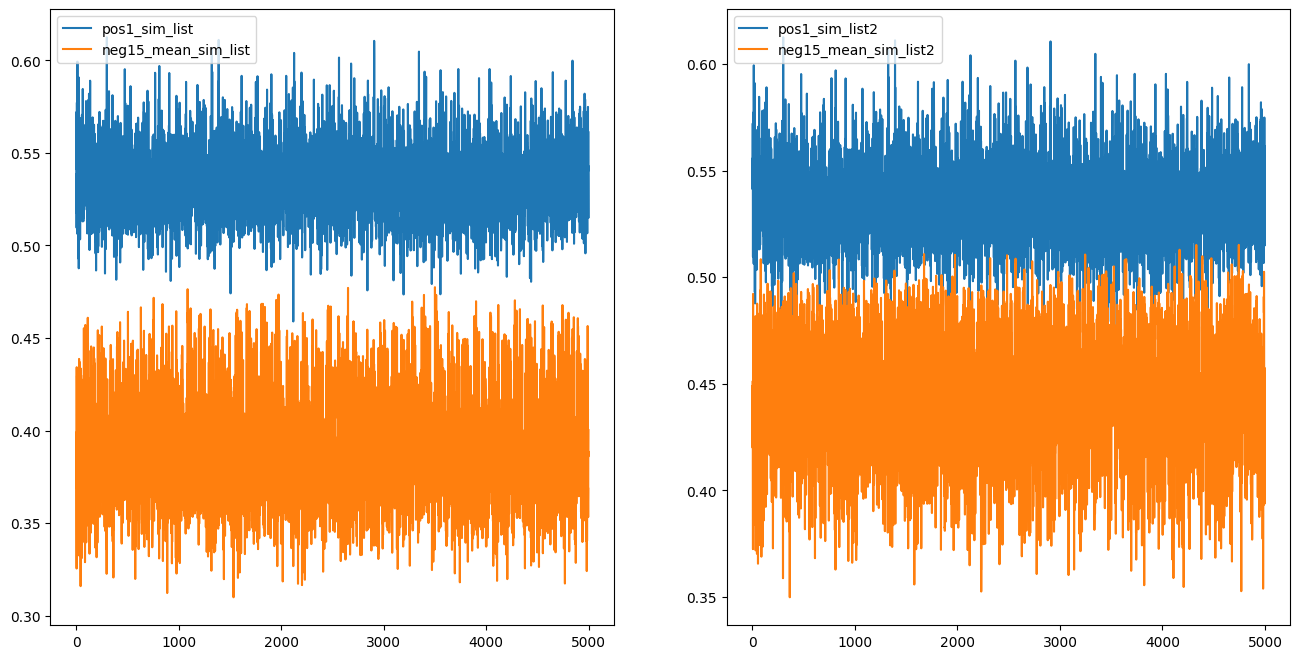

In [ ]:
## 5000个样本画图对比 正/负样本的 cos_sim

import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.plot(range(5000), pos1_sim_list)
plt.plot(range(5000), neg15_mean_sim_list)
plt.legend(['pos1_sim_list', 'neg15_mean_sim_list'], loc='upper left')
plt.subplot(1,2,2)
plt.plot(range(5000), pos1_sim_list2)
plt.plot(range(5000), neg15_mean_sim_list2)
plt.legend(['pos1_sim_list2', 'neg15_mean_sim_list2'], loc='upper left')
plt.show()


#### score 差异图

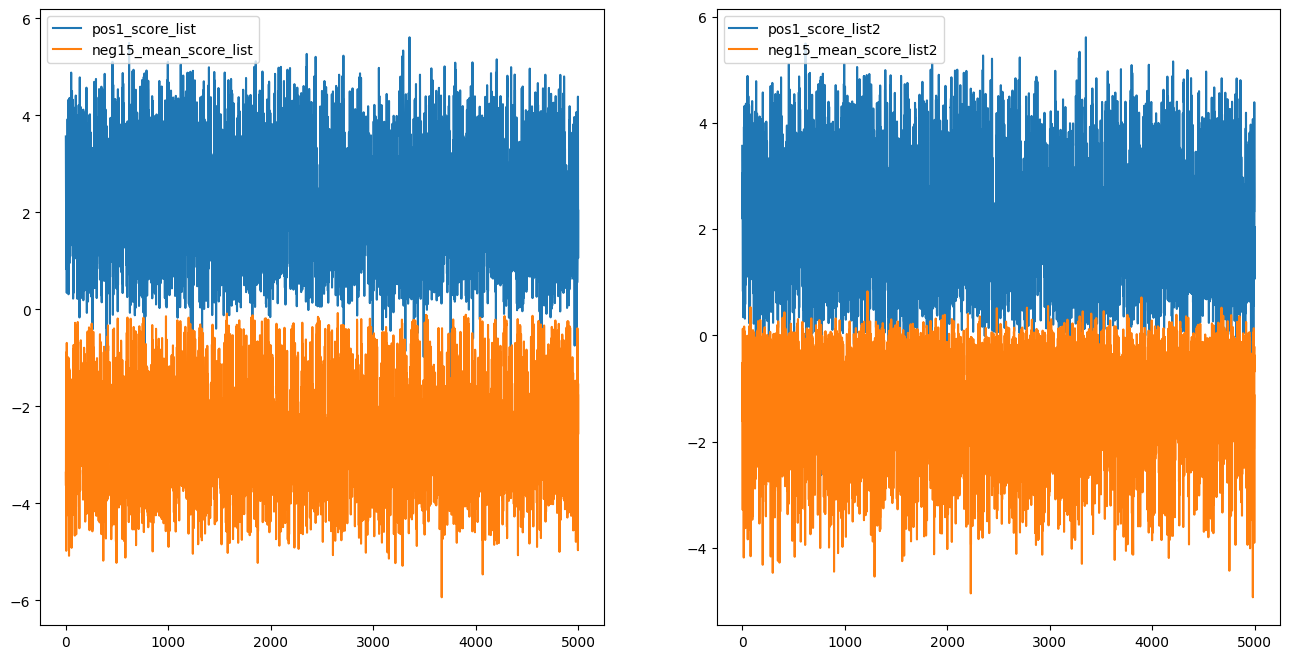

In [158]:
## 5000个样本画图对比 正/负样本的 score

import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.plot(range(5000), pos1_score_list)
plt.plot(range(5000), neg15_mean_score_list)
plt.legend(['pos1_score_list', 'neg15_mean_score_list'], loc='upper left')
plt.subplot(1,2,2)
plt.plot(range(5000), pos1_score_list2)
plt.plot(range(5000), neg15_mean_score_list2)
plt.legend(['pos1_score_list2', 'neg15_mean_score_list2'], loc='upper left')
plt.show()

In [ ]:
## top32-128 和 top10-32 的pos_top1是相同的
np.sum([i-j for i,j in zip(pos1_score_list,pos1_score_list2)])

0.0

np.mean(diff_score_list),np.max(diff_score_list),np.min(diff_score_list) :  4.648568091313811 10.0791965842247 -0.7985580717523892
np.mean(diff_score_list2),np.max(diff_score_list2),np.min(diff_score_list2) :  3.376815753844325 9.504473082224528 -1.0368241670231024


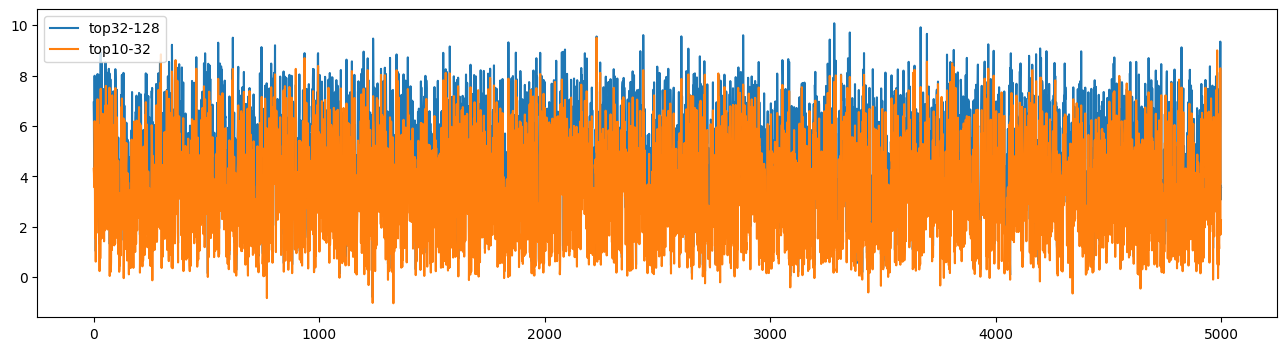

np.mean(diff_diff),np.max(diff_diff),np.min(diff_diff) :  1.2717523374694866 4.257442223280668 -1.5060464104016615


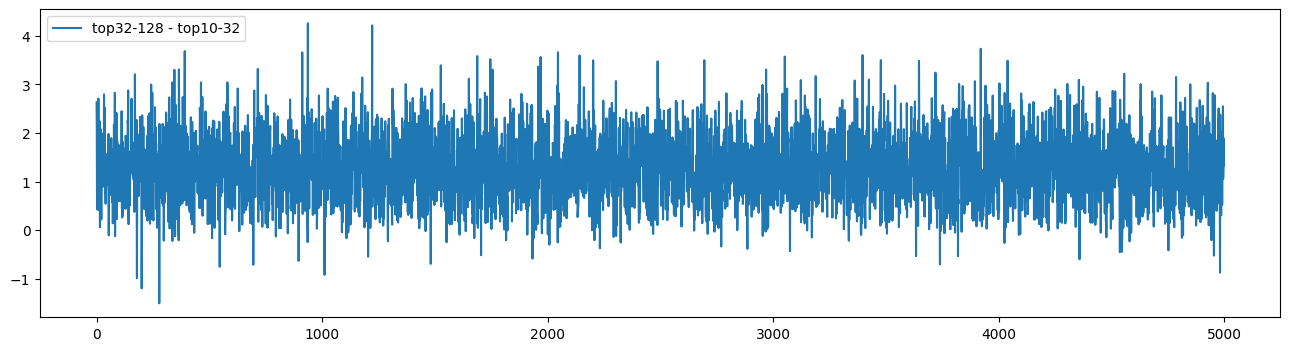

In [178]:
## 5000个样本画图对比 正/负样本的 score的差值
diff_score_list=[]
for pos1_score, neg15_mean_score in zip(pos1_score_list, neg15_mean_score_list):
    diff_score_list.append(pos1_score - neg15_mean_score)

diff_score_list2=[]
for pos1_score, neg15_mean_score in zip(pos1_score_list2, neg15_mean_score_list2):
    diff_score_list2.append(pos1_score - neg15_mean_score)

print("np.mean(diff_score_list),np.max(diff_score_list),np.min(diff_score_list) : ", np.mean(diff_score_list),np.max(diff_score_list),np.min(diff_score_list))
print("np.mean(diff_score_list2),np.max(diff_score_list2),np.min(diff_score_list2) : ",np.mean(diff_score_list2),np.max(diff_score_list2),np.min(diff_score_list2))

import matplotlib.pyplot as plt

plt.figure(figsize=(16,4))
# plt.subplot(1,2,1)
plt.plot(range(5000), diff_score_list)
plt.plot(range(5000), diff_score_list2)
plt.legend(['top32-128', 'top10-32'], loc='upper left')
plt.show()


diff_diff = [diff-diff2 for diff, diff2 in zip(diff_score_list, diff_score_list2)]
print("np.mean(diff_diff),np.max(diff_diff),np.min(diff_diff) : ",np.mean(diff_diff),np.max(diff_diff),np.min(diff_diff))
plt.figure(figsize=(16,4))
# plt.subplot(1,2,1)
plt.plot(range(5000), diff_diff)
plt.legend(['top32-128 - top10-32'], loc='upper left')
plt.show()